# REVENUE INDEX — MULTI-SCENARIO (3 penetration × 3 temperature = 9 combinations)
=================================================================================
Computes RI(t) = P(t) · CR_sim(t) for all 9 scenario combinations.
 
Penetration scenarios (from mc_physical_variables_{key}.parquet):
  current_trend  → 30% solar share by 2050
  pniec          → 45% solar share by 2050  (PNIEC 2024)
  entso_e        → 60% solar share by 2050  (ENTSO-E DE)
 
Temperature scenarios (SSP delta from df_temperature_scenarios.parquet):
  baseline  → historical trend only   (no SSP adjustment)
  ssp126    → aggressive mitigation   (delta < 0 vs baseline)
  ssp585    → high emissions          (delta > 0 vs baseline)
 
Reference scenario for value-loss analysis: (pniec, baseline)
 
Steps:
  Step 0  — Imports, paths, constants, combination matrix
  Step 1  — NOCT uplift profile
  Step 2  — Load shared arrays (GHI_sim, T_sim) + SSP deltas
  Step 3  — Compute T_eff, f_temp, P(t) for each temp scenario [×3]
  Step 4  — Compute RI(t) for all 9 combinations
  Step 5  — Aggregate to annual + risk metrics
  Step 6  — Save results
  Step 7  — Individual fan charts (3×3 grid)
  Step 8  — Cross-scenario comparison plots
  Step 9  — Waterfall decomposition of Revenue-at-Risk

In [1]:
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from scipy.stats import gaussian_kde
from pathlib import Path
import pickle
import calendar
import warnings
warnings.filterwarnings("ignore")

In [2]:
# ── paths ─────────────────────────────────────────────────────────────────────
data_sim      = Path("../../Data/Simulated")
data_modelled = Path("../../Data/Modelled")
data_cleaned  = Path("../../Data/Cleaned")
data_results  = Path("../../Data/Results")
models_path   = Path("../../Code/Models")
data_results.mkdir(parents=True, exist_ok=True)

In [3]:
# ── physical constants ────────────────────────────────────────────────────────
G_STC  = 1000.0   # W/m²
T_STC  = 25.0     # °C
GAMMA  = -0.0043   # /°C
PR     = 0.80
NOCT   = 45.0     # °C

In [4]:
# ── scenario definitions ──────────────────────────────────────────────────────
PEN_KEYS   = ["current_trend", "pniec", "entso_e"]
TEMP_KEYS  = ["baseline",      "ssp126", "ssp585"]
 
PEN_LABELS = {
    "current_trend": "Current Trend (30%)",
    "pniec":         "PNIEC 2024 (45%)",
    "entso_e":       "ENTSO-E DE (60%)",
}
TEMP_LABELS = {
    "baseline": "Baseline",
    "ssp126":   "SSP1-2.6",
    "ssp585":   "SSP5-8.5",
}
 
# 9-combination matrix
COMBINATIONS = [
    {"scenario_id": i*3+j,
     "pen_key":  pk,
     "temp_key": tk,
     "label":    f"{PEN_LABELS[pk]} | {TEMP_LABELS[tk]}"}
    for i, pk in enumerate(PEN_KEYS)
    for j, tk in enumerate(TEMP_KEYS)
]
 
# reference scenario: (pniec, baseline)
REF_PEN  = "pniec"
REF_TEMP = "baseline"
REF_ID   = next(c["scenario_id"] for c in COMBINATIONS
                if c["pen_key"]==REF_PEN and c["temp_key"]==REF_TEMP)
 
# visual settings
PEN_COLORS  = {"current_trend":"goldenrod", "pniec":"steelblue",
               "entso_e":"crimson"}
TEMP_STYLES = {"baseline":"-", "ssp126":"--", "ssp585":"-."}
 
print("── Step 0: Configuration ────────────────────────────────────────")
print(f"  G_STC={G_STC}  T_STC={T_STC}°C  γ={GAMMA}  PR={PR}  NOCT={NOCT}°C")
print(f"  Penetration scenarios : {PEN_KEYS}")
print(f"  Temperature scenarios : {TEMP_KEYS}")
print(f"  Total combinations   : {len(COMBINATIONS)}")
print(f"  Reference scenario   : ({REF_PEN}, {REF_TEMP})  id={REF_ID}")
print(f"\n  Combination matrix:")
for c in COMBINATIONS:
    ref = " ← REFERENCE" if c["scenario_id"] == REF_ID else ""
    print(f"    [{c['scenario_id']}] {c['label']}{ref}")

── Step 0: Configuration ────────────────────────────────────────
  G_STC=1000.0  T_STC=25.0°C  γ=-0.0043  PR=0.8  NOCT=45.0°C
  Penetration scenarios : ['current_trend', 'pniec', 'entso_e']
  Temperature scenarios : ['baseline', 'ssp126', 'ssp585']
  Total combinations   : 9
  Reference scenario   : (pniec, baseline)  id=3

  Combination matrix:
    [0] Current Trend (30%) | Baseline
    [1] Current Trend (30%) | SSP1-2.6
    [2] Current Trend (30%) | SSP5-8.5
    [3] PNIEC 2024 (45%) | Baseline ← REFERENCE
    [4] PNIEC 2024 (45%) | SSP1-2.6
    [5] PNIEC 2024 (45%) | SSP5-8.5
    [6] ENTSO-E DE (60%) | Baseline
    [7] ENTSO-E DE (60%) | SSP1-2.6
    [8] ENTSO-E DE (60%) | SSP5-8.5


# STEP 1 — NOCT uplift profile

In [5]:

# ─────────────────────────────────────────────────────────────────────────────
 
print(f"\n── Step 1: NOCT uplift profile ──────────────────────────────────")
 
noct_path = models_path / "Temperature" / "noct_uplift_params.pkl"
 
if noct_path.exists():
    with open(noct_path, "rb") as f:
        noct_params = pickle.load(f)
    uplift_by_doy = noct_params["uplift_by_doy"]
    print(f"  Loaded  : {len(uplift_by_doy)} doy entries")
    print(f"  Mean    : {np.mean(list(uplift_by_doy.values())):.2f}°C")
else:
    raise FileNotFoundError(
        "noct_uplift_params.pkl not found.\n"
        "Run the Revenue Index notebook Step 1 first to calibrate NOCT."
    )


── Step 1: NOCT uplift profile ──────────────────────────────────
  Loaded  : 366 doy entries
  Mean    : 15.64°C


# STEP 2 — Load shared arrays and SSP deltas

In [6]:

# ─────────────────────────────────────────────────────────────────────────────
 
print(f"\n── Step 2: Load shared arrays and SSP deltas ────────────────────")
 
# ── 2.1 load one penetration parquet to get shared arrays ────────────────────
# T_sim and GHI_sim are identical across all penetration parquets
# Load from the first key to avoid redundancy
ref_parquet = data_sim / f"mc_physical_variables_{PEN_KEYS[0]}.parquet"
print(f"  Loading shared arrays from: {ref_parquet.name}")
df_ref = pd.read_parquet(ref_parquet)
df_ref["date"] = pd.to_datetime(df_ref["date"])
df_ref = df_ref.sort_values(["sim_id","date"]).reset_index(drop=True)
 
N_SIM  = int(df_ref["sim_id"].nunique())
N_DAYS = int(df_ref.groupby("sim_id").size().iloc[0])
dates_pd   = pd.date_range(
    start=df_ref["date"].min(), end=df_ref["date"].max(), freq="D"
)
years_arr  = dates_pd.year
doys_arr   = dates_pd.dayofyear
months_arr = dates_pd.month
 
print(f"  N_SIM={N_SIM}  N_DAYS={N_DAYS}  "
      f"({dates_pd[0].date()} → {dates_pd[-1].date()})")
 
# shared arrays — shape (N_SIM, N_DAYS)
T_sim_baseline = df_ref["T_sim"].values.reshape(N_SIM, N_DAYS)
GHI_sim        = df_ref["GHI_sim"].values.reshape(N_SIM, N_DAYS)
KT_sim         = df_ref["KT_sim"].values.reshape(N_SIM, N_DAYS)
 
print(f"  T_sim  : mean={T_sim_baseline.mean():.2f}°C")
print(f"  GHI_sim: mean={GHI_sim.mean():.0f} Wh/m²")
del df_ref   # free memory


── Step 2: Load shared arrays and SSP deltas ────────────────────
  Loading shared arrays from: mc_physical_variables_current_trend.parquet
  N_SIM=1000  N_DAYS=9131  (2026-01-01 → 2050-12-31)
  T_sim  : mean=14.65°C
  GHI_sim: mean=4128 Wh/m²


In [7]:
# ── 2.2 load CR_sim for each penetration scenario ────────────────────────────
CR_sim_pen = {}
for pen_key in PEN_KEYS:
    fpath = data_sim / f"mc_physical_variables_{pen_key}.parquet"
    df_p  = pd.read_parquet(fpath, columns=["sim_id","date","CR_sim"])
    df_p  = df_p.sort_values(["sim_id","date"]).reset_index(drop=True)
    CR_sim_pen[pen_key] = df_p["CR_sim"].values.reshape(N_SIM, N_DAYS)
    print(f"  CR [{pen_key:<15}]: mean={CR_sim_pen[pen_key].mean():.4f}  "
          f"p50(2050)={np.percentile(CR_sim_pen[pen_key][:,years_arr==2050],50):.4f}")
    del df_p

  CR [current_trend  ]: mean=0.7574  p50(2050)=0.6606
  CR [pniec          ]: mean=0.6799  p50(2050)=0.5907
  CR [entso_e        ]: mean=0.6528  p50(2050)=0.5824


In [8]:
# ── 2.3 load SSP temperature deltas ──────────────────────────────────────────
df_ssp = pd.read_parquet(data_cleaned / "df_temperature_scenarios.parquet")
df_ssp["date"] = pd.to_datetime(df_ssp["date"])
df_ssp = df_ssp.set_index("date").reindex(dates_pd)
 
# SSP delta arrays (N_DAYS,) — additive on T_sim_baseline
delta_temp = {
    "baseline": np.zeros(N_DAYS),
    "ssp126":   df_ssp["delta_ssp126"].values,
    "ssp585":   df_ssp["delta_ssp585"].values,
}
print(f"\n  SSP temperature deltas (2050 annual mean):")
for tk, arr in delta_temp.items():
    d50 = float(arr[years_arr == 2050].mean())
    print(f"    {TEMP_LABELS[tk]:<12}: {d50:+.3f}°C by 2050")


  SSP temperature deltas (2050 annual mean):
    Baseline    : +0.000°C by 2050
    SSP1-2.6    : -0.607°C by 2050
    SSP5-8.5    : +0.644°C by 2050


In [9]:
# ── 2.4 NOCT uplift for simulation calendar ───────────────────────────────────
uplift_default = float(np.mean(list(uplift_by_doy.values())))
uplift_sim     = np.array([
    uplift_by_doy.get(int(d), uplift_default)
    for d in doys_arr
])   # shape (N_DAYS,)

# STEP 3 — Compute factors

T_eff, f_temp, P(t) for each temperature scenario [×3]

In [10]:

# ─────────────────────────────────────────────────────────────────────────────
# T_sim, GHI_sim are shared → P depends only on temperature scenario
# P is computed 3 times (not 9) and reused across penetration scenarios
 
print(f"\n── Step 3: T_eff, f_temp, P(t) per temperature scenario ─────────")
 
P_temp  = {}   # dict: temp_key → (N_SIM, N_DAYS)
n_years = len(np.unique(years_arr))
 
for temp_key in TEMP_KEYS:
    # apply SSP delta — broadcast (N_DAYS,) across (N_SIM, N_DAYS)
    delta_arr = delta_temp[temp_key]   # shape (N_DAYS,)
    T_sim_t   = T_sim_baseline + delta_arr[np.newaxis, :]
 
    # NOCT effective cell temperature
    T_eff = T_sim_t + uplift_sim[np.newaxis, :]
 
    # production efficiency
    f_temp = 1 + GAMMA * (T_eff - T_STC)
 
    # unit energy yield
    P = (GHI_sim / G_STC) * f_temp * PR
    P_temp[temp_key] = P
 
    # stats
    P_nz    = P[P > 0]
    ann_mean = P.sum(axis=1).mean() / n_years
    print(f"  {TEMP_LABELS[temp_key]:<12}: "
          f"P mean={P_nz.mean():.4f} kWh/kWp/day  "
          f"annual={ann_mean:.1f} kWh/kWp/yr  "
          f"T_eff mean={T_eff.mean():.2f}°C")


── Step 3: T_eff, f_temp, P(t) per temperature scenario ─────────


  Baseline    : P mean=3.1491 kWh/kWp/day  annual=1150.2 kWh/kWp/yr  T_eff mean=30.29°C
  SSP1-2.6    : P mean=3.1521 kWh/kWp/day  annual=1151.3 kWh/kWp/yr  T_eff mean=30.08°C
  SSP5-8.5    : P mean=3.1459 kWh/kWp/day  annual=1149.0 kWh/kWp/yr  T_eff mean=30.52°C


# STEP 4 — Compute RI(t) for all 9 combinations

In [11]:
print(f"\n── Step 4: RI(t) for all 9 combinations ─────────────────────────")
 
RI_annual = {}    # dict: (pen_key, temp_key) → (N_SIM, n_years)
P_annual  = {}
CR_annual = {}
T_annual  = {}
 
years_unique = sorted(np.unique(years_arr))
 
for comb in COMBINATIONS:
    pen_key  = comb["pen_key"]
    temp_key = comb["temp_key"]
    key      = (pen_key, temp_key)
 
    # RI(t) = P(t) * CR_sim(t)
    RI_arr = P_temp[temp_key] * CR_sim_pen[pen_key]   # (N_SIM, N_DAYS)
 
    # aggregate to annual
    RI_yr  = np.zeros((N_SIM, len(years_unique)))
    P_yr   = np.zeros((N_SIM, len(years_unique)))
    CR_yr  = np.zeros((N_SIM, len(years_unique)))
    T_yr   = np.zeros((N_SIM, len(years_unique)))
 
    for yi, yr in enumerate(years_unique):
        m = years_arr == yr
        RI_yr[:, yi]  = RI_arr[:, m].sum(axis=1)
        P_yr[:, yi]   = P_temp[temp_key][:, m].sum(axis=1)
        CR_yr[:, yi]  = CR_sim_pen[pen_key][:, m].mean(axis=1)
        T_yr[:, yi]   = T_sim_baseline[:, m].mean(axis=1) + \
                         float(delta_temp[temp_key][m].mean())
 
    RI_annual[key] = RI_yr
    P_annual[key]  = P_yr
    CR_annual[key] = CR_yr
    T_annual[key]  = T_yr
 
    ri_mean_2026 = RI_yr[:, 0].mean()
    ri_mean_2050 = RI_yr[:, -1].mean()
    ri_p10_2050  = np.percentile(RI_yr[:, -1], 10)
    print(f"  [{comb['scenario_id']}] {comb['label'][:45]:<45}"
          f"  2026={ri_mean_2026:.1f}  2050={ri_mean_2050:.1f}  P10={ri_p10_2050:.1f}")


── Step 4: RI(t) for all 9 combinations ─────────────────────────
  [0] Current Trend (30%) | Baseline                 2026=1059.2  2050=712.1  P10=479.6
  [1] Current Trend (30%) | SSP1-2.6                 2026=1059.2  2050=714.0  P10=480.9
  [2] Current Trend (30%) | SSP5-8.5                 2026=1059.2  2050=710.0  P10=478.2
  [3] PNIEC 2024 (45%) | Baseline                    2026=1057.1  2050=631.7  P10=397.9
  [4] PNIEC 2024 (45%) | SSP1-2.6                    2026=1057.1  2050=633.4  P10=399.0
  [5] PNIEC 2024 (45%) | SSP5-8.5                    2026=1057.1  2050=629.9  P10=396.8
  [6] ENTSO-E DE (60%) | Baseline                    2026=1055.7  2050=622.2  P10=388.4
  [7] ENTSO-E DE (60%) | SSP1-2.6                    2026=1055.8  2050=623.9  P10=389.5
  [8] ENTSO-E DE (60%) | SSP5-8.5                    2026=1055.7  2050=620.4  P10=387.3


# STEP 5 — Risk metrics and value-loss vs reference

In [12]:

# ─────────────────────────────────────────────────────────────────────────────
 
print(f"\n── Step 5: Risk metrics ─────────────────────────────────────────")
 
ref_key = (REF_PEN, REF_TEMP)
records = []
 
for comb in COMBINATIONS:
    key = (comb["pen_key"], comb["temp_key"])
    for yi, yr in enumerate(years_unique):
        ri_paths = RI_annual[key][:, yi]
        ref_mean = RI_annual[ref_key][:, yi].mean()
        ref_p10  = np.percentile(RI_annual[ref_key][:, yi], 10)
 
        # Expected Shortfall at 10%
        p10_val  = np.percentile(ri_paths, 10)
        es10     = float(ri_paths[ri_paths <= p10_val].mean())
 
        records.append({
            "scenario_id":   comb["scenario_id"],
            "pen_scenario":  comb["pen_key"],
            "temp_scenario": comb["temp_key"],
            "label":         comb["label"],
            "year":          int(yr),
            "RI_mean":       float(ri_paths.mean()),
            "RI_std":        float(ri_paths.std()),
            "RI_p5":         float(np.percentile(ri_paths,  5)),
            "RI_p10":        float(np.percentile(ri_paths, 10)),
            "RI_p25":        float(np.percentile(ri_paths, 25)),
            "RI_p50":        float(np.percentile(ri_paths, 50)),
            "RI_p75":        float(np.percentile(ri_paths, 75)),
            "RI_p90":        float(np.percentile(ri_paths, 90)),
            "RI_p95":        float(np.percentile(ri_paths, 95)),
            "ES10":          es10,
            "CoV":           float(ri_paths.std() / ri_paths.mean()),
            "P_annual_mean": float(P_annual[key][:, yi].mean()),
            "CR_annual_mean":float(CR_annual[key][:, yi].mean()),
            "T_annual_mean": float(T_annual[key][:, yi].mean()),
            # value loss vs reference (PNIEC, Baseline)
            "delta_mean_vs_ref":float(ri_paths.mean() - ref_mean),
            "delta_p10_vs_ref": float(p10_val - ref_p10),
        })
 
df_metrics = pd.DataFrame(records)
print(f"  Risk metrics: {len(df_metrics)} rows  "
      f"({len(COMBINATIONS)} scenarios × {len(years_unique)} years)")
print(f"\n  2050 summary  (RI mean | P10 | delta_mean_vs_ref):")
print(f"  {'Scenario':<45}  {'mean':>8}  {'P10':>8}  {'Δ vs ref':>10}")
print(f"  {'-'*45}  {'-'*8}  {'-'*8}  {'-'*10}")
for comb in COMBINATIONS:
    row = df_metrics[
        (df_metrics["scenario_id"]==comb["scenario_id"]) &
        (df_metrics["year"]==2050)
    ].iloc[0]
    ref = " ← REF" if comb["scenario_id"]==REF_ID else ""
    print(f"  {comb['label'][:45]:<45}  "
          f"{row['RI_mean']:>8.1f}  "
          f"{row['RI_p10']:>8.1f}  "
          f"{row['delta_mean_vs_ref']:>+10.1f}{ref}")


── Step 5: Risk metrics ─────────────────────────────────────────
  Risk metrics: 225 rows  (9 scenarios × 25 years)

  2050 summary  (RI mean | P10 | delta_mean_vs_ref):
  Scenario                                           mean       P10    Δ vs ref
  ---------------------------------------------  --------  --------  ----------
  Current Trend (30%) | Baseline                    712.1     479.6       +80.4
  Current Trend (30%) | SSP1-2.6                    714.0     480.9       +82.3
  Current Trend (30%) | SSP5-8.5                    710.0     478.2       +78.3
  PNIEC 2024 (45%) | Baseline                       631.7     397.9        +0.0 ← REF
  PNIEC 2024 (45%) | SSP1-2.6                       633.4     399.0        +1.7
  PNIEC 2024 (45%) | SSP5-8.5                       629.9     396.8        -1.8
  ENTSO-E DE (60%) | Baseline                       622.2     388.4        -9.5
  ENTSO-E DE (60%) | SSP1-2.6                       623.9     389.5        -7.8
  ENTSO-E DE (60%) | S

# STEP 6 — Save results

In [13]:

# ─────────────────────────────────────────────────────────────────────────────
 
print(f"\n── Step 6: Save results ─────────────────────────────────────────")
 
# ── compact metrics summary (no raw paths) ────────────────────────────────────
out_metrics = data_results / "risk_metrics_summary.parquet"
df_metrics["pen_scenario"]  = df_metrics["pen_scenario"].astype("category")
df_metrics["temp_scenario"] = df_metrics["temp_scenario"].astype("category")
df_metrics.to_parquet(out_metrics, index=False, compression="zstd")
print(f"  Risk metrics: {out_metrics.name}  "
      f"({out_metrics.stat().st_size/1e6:.1f} MB)  "
      f"{len(df_metrics)} rows")
 
# ── full annual paths (float32 + categorical) ─────────────────────────────────
out_annual  = data_results / "ri_annual_results_multiscenario.parquet"
annual_recs = []
 
for comb in COMBINATIONS:
    key = (comb["pen_key"], comb["temp_key"])
    for sim_id in range(N_SIM):
        for yi, yr in enumerate(years_unique):
            annual_recs.append({
                "scenario_id":   np.int16(comb["scenario_id"]),
                "pen_scenario":  comb["pen_key"],
                "temp_scenario": comb["temp_key"],
                "sim_id":        np.int16(sim_id),
                "year":          np.int16(yr),
                "RI_annual":     np.float32(RI_annual[key][sim_id, yi]),
                "P_annual":      np.float32(P_annual[key][sim_id, yi]),
                "CR_annual":     np.float32(CR_annual[key][sim_id, yi]),
                "T_annual":      np.float32(T_annual[key][sim_id, yi]),
            })
 
df_annual = pd.DataFrame(annual_recs)
df_annual["pen_scenario"]  = df_annual["pen_scenario"].astype("category")
df_annual["temp_scenario"] = df_annual["temp_scenario"].astype("category")
df_annual.to_parquet(out_annual, index=False, compression="zstd")
print(f"  Annual paths: {out_annual.name}  "
      f"({out_annual.stat().st_size/1e6:.1f} MB)  "
      f"{len(df_annual):,} rows")


── Step 6: Save results ─────────────────────────────────────────
  Risk metrics: risk_metrics_summary.parquet  (0.0 MB)  225 rows
  Annual paths: ri_annual_results_multiscenario.parquet  (3.4 MB)  225,000 rows


# STEP 7 — Individual fan charts (3×3 grid)


── Step 7: 3×3 fan chart grid ───────────────────────────────────


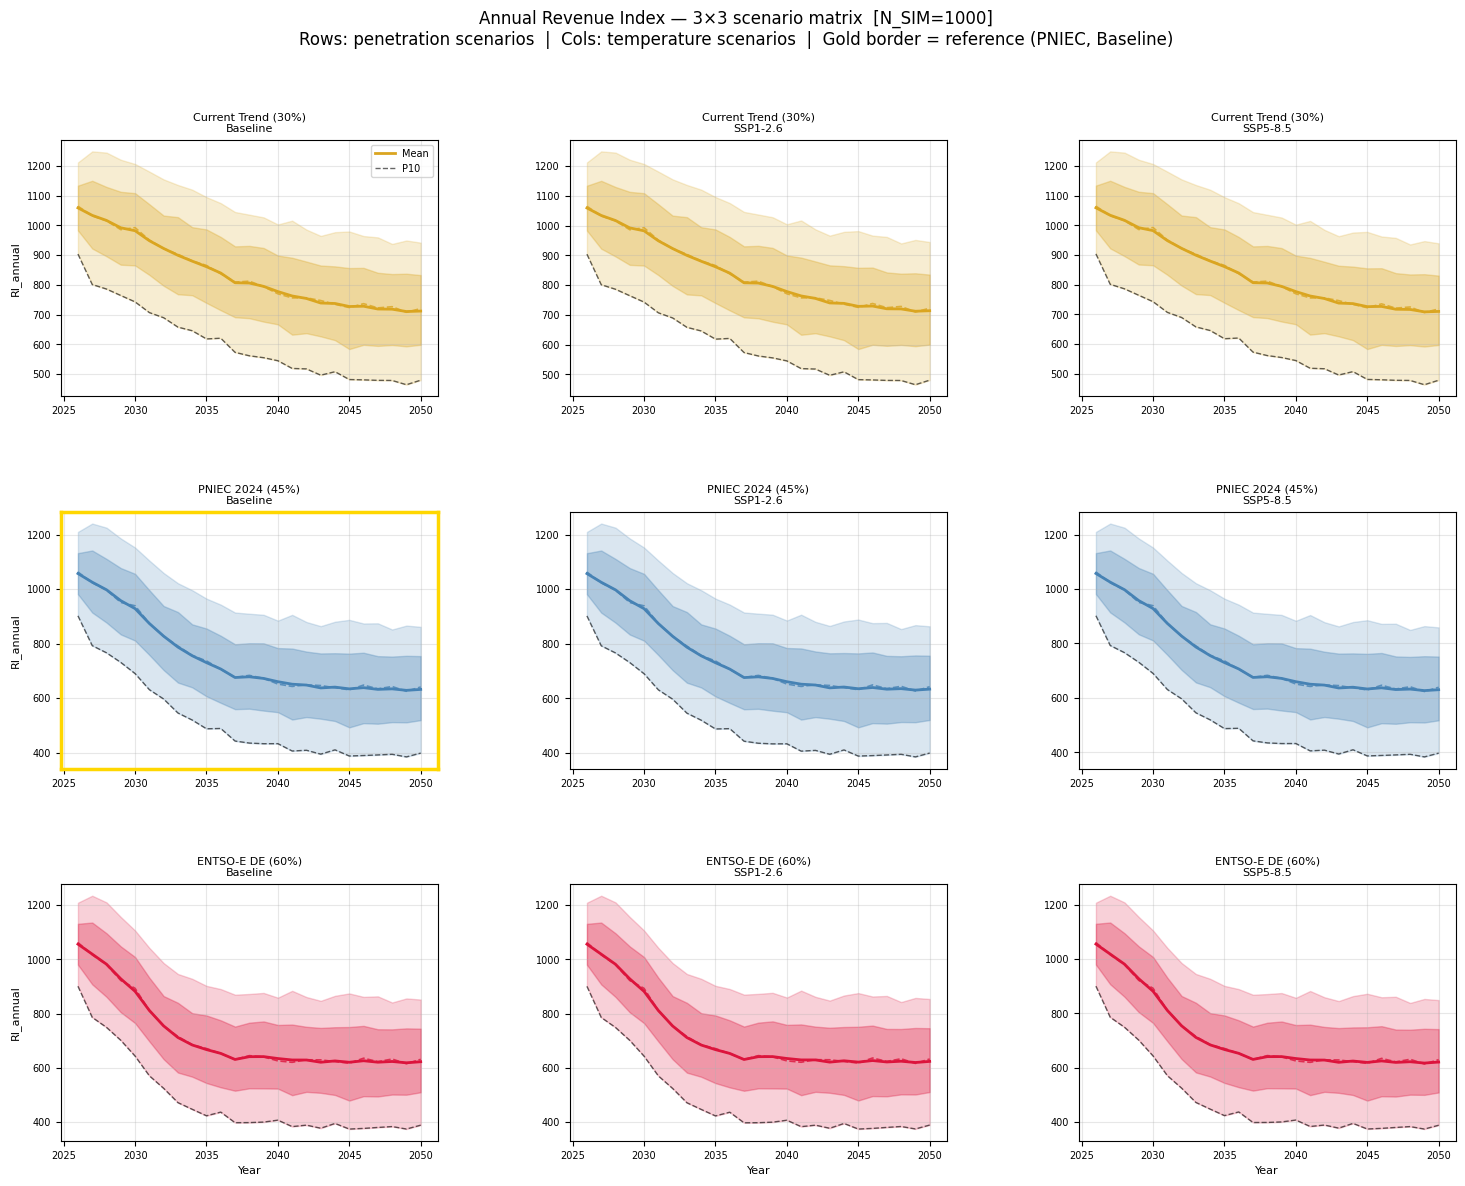

In [14]:

# ─────────────────────────────────────────────────────────────────────────────
 
print(f"\n── Step 7: 3×3 fan chart grid ───────────────────────────────────")
 
fig = plt.figure(figsize=(18, 13))
gs  = gridspec.GridSpec(3, 3, hspace=0.45, wspace=0.35)
 
for i, pen_key in enumerate(PEN_KEYS):
    for j, temp_key in enumerate(TEMP_KEYS):
        key  = (pen_key, temp_key)
        ax   = fig.add_subplot(gs[i, j])
        RI_m = df_metrics[
            (df_metrics["pen_scenario"]==pen_key) &
            (df_metrics["temp_scenario"]==temp_key)
        ].sort_values("year")
        color = PEN_COLORS[pen_key]
 
        ax.fill_between(RI_m["year"], RI_m["RI_p10"], RI_m["RI_p90"],
                        alpha=0.20, color=color)
        ax.fill_between(RI_m["year"], RI_m["RI_p25"], RI_m["RI_p75"],
                        alpha=0.30, color=color)
        ax.plot(RI_m["year"], RI_m["RI_mean"],  color=color, lw=2.0,
                label="Mean")
        ax.plot(RI_m["year"], RI_m["RI_p50"],   color=color, lw=1.2,
                ls="--", alpha=0.8)
        ax.plot(RI_m["year"], RI_m["RI_p10"],   color="black", lw=1.0,
                ls="--", alpha=0.6, label="P10")
 
        # reference border
        is_ref = (pen_key==REF_PEN and temp_key==REF_TEMP)
        if is_ref:
            for spine in ax.spines.values():
                spine.set_edgecolor("gold")
                spine.set_linewidth(2.5)
 
        ax.set_title(f"{PEN_LABELS[pen_key]}\n{TEMP_LABELS[temp_key]}",
                     fontsize=8)
        if i == 2: ax.set_xlabel("Year", fontsize=8)
        if j == 0: ax.set_ylabel("RI_annual", fontsize=8)
        ax.tick_params(labelsize=7)
        ax.grid(alpha=0.3)
        if i==0 and j==0:
            ax.legend(fontsize=7)
 
fig.suptitle(
    f"Annual Revenue Index — 3×3 scenario matrix  [N_SIM={N_SIM}]\n"
    f"Rows: penetration scenarios  |  Cols: temperature scenarios  |  "
    f"Gold border = reference (PNIEC, Baseline)",
    fontsize=12
)
plt.show()


── Step 8: Cross-scenario comparison ───────────────────────────


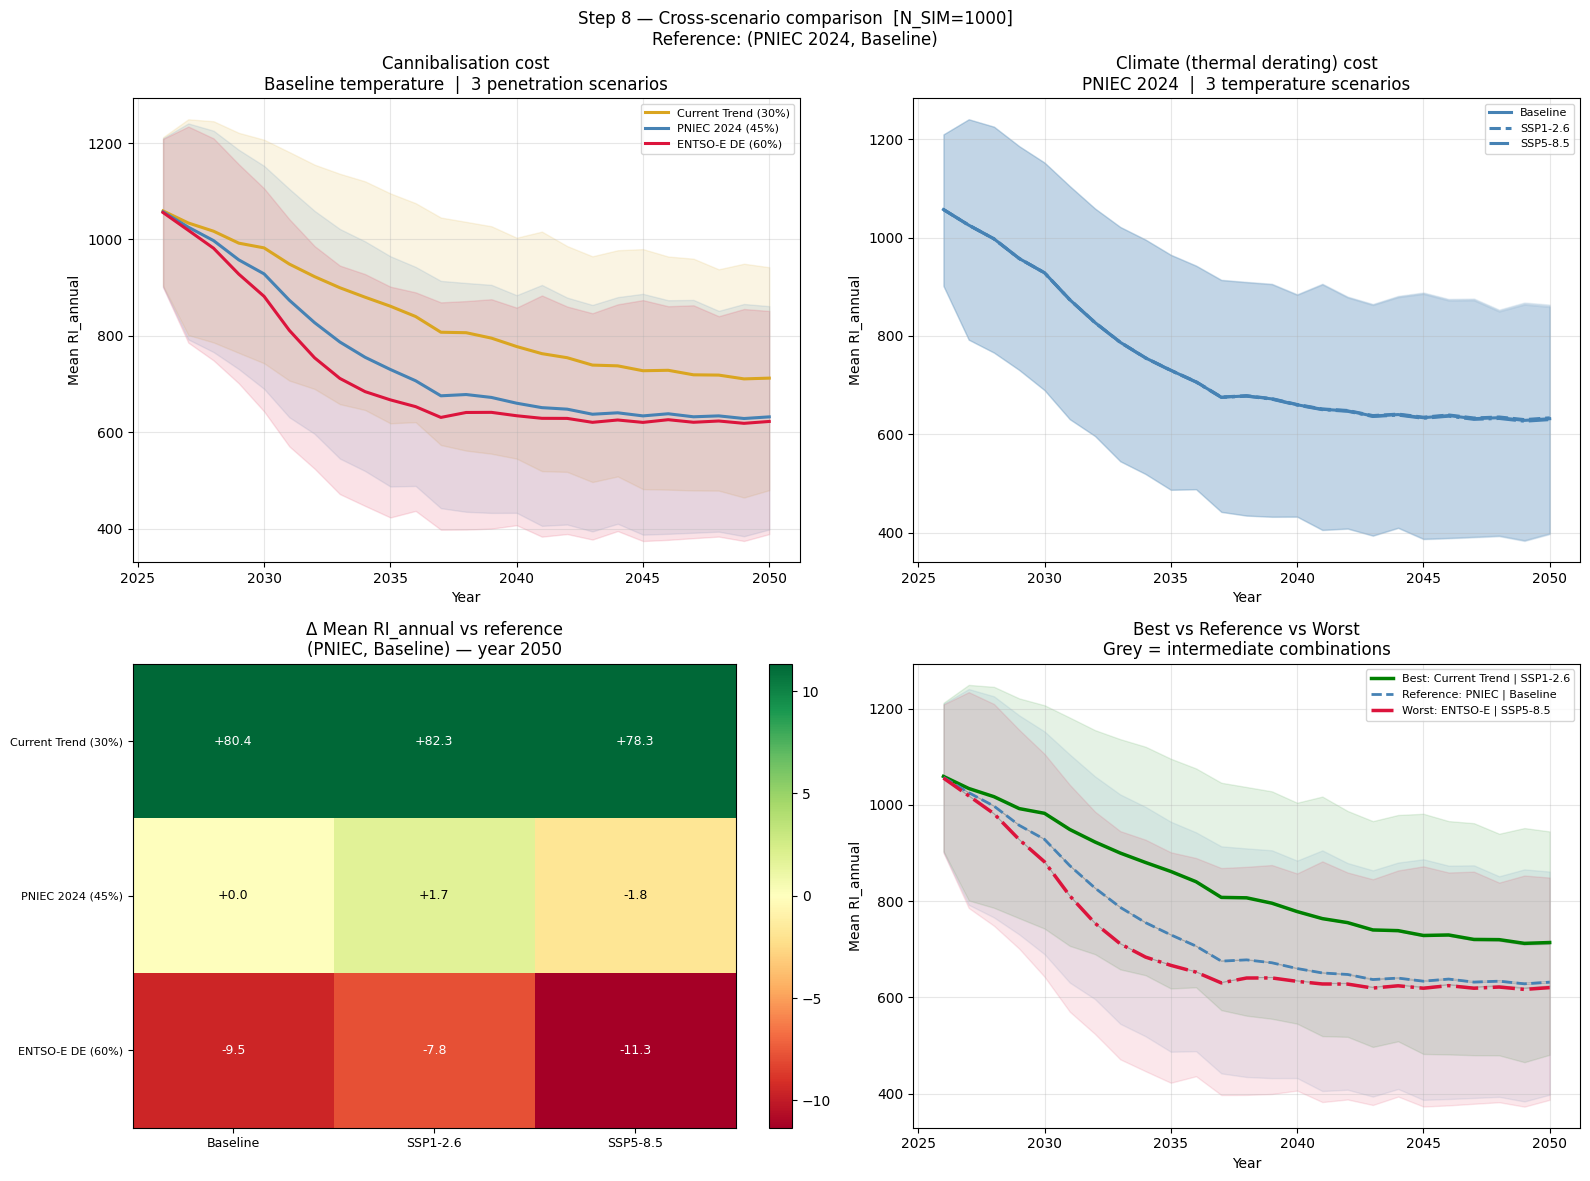

In [15]:
# STEP 8 — Cross-scenario comparison plots
# ─────────────────────────────────────────────────────────────────────────────
 
print(f"\n── Step 8: Cross-scenario comparison ───────────────────────────")
 
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
 
# ── top-left: cannibalisation cost (baseline temp, all pen scenarios) ─────────
ax = axes[0, 0]
for pen_key in PEN_KEYS:
    RI_m = df_metrics[
        (df_metrics["pen_scenario"]==pen_key) &
        (df_metrics["temp_scenario"]=="baseline")
    ].sort_values("year")
    ax.fill_between(RI_m["year"], RI_m["RI_p10"], RI_m["RI_p90"],
                    alpha=0.12, color=PEN_COLORS[pen_key])
    ax.plot(RI_m["year"], RI_m["RI_mean"],
            color=PEN_COLORS[pen_key], lw=2.2,
            label=PEN_LABELS[pen_key])
ax.set_title("Cannibalisation cost\nBaseline temperature  |  3 penetration scenarios")
ax.set_xlabel("Year"); ax.set_ylabel("Mean RI_annual")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
 
# ── top-right: climate cost (PNIEC pen, all temp scenarios) ───────────────────
ax = axes[0, 1]
for temp_key in TEMP_KEYS:
    RI_m = df_metrics[
        (df_metrics["pen_scenario"]=="pniec") &
        (df_metrics["temp_scenario"]==temp_key)
    ].sort_values("year")
    ax.fill_between(RI_m["year"], RI_m["RI_p10"], RI_m["RI_p90"],
                    alpha=0.12, color="steelblue")
    ax.plot(RI_m["year"], RI_m["RI_mean"],
            color="steelblue", lw=2.2, ls=TEMP_STYLES[temp_key],
            label=TEMP_LABELS[temp_key])
ax.set_title("Climate (thermal derating) cost\nPNIEC 2024  |  3 temperature scenarios")
ax.set_xlabel("Year"); ax.set_ylabel("Mean RI_annual")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
 
# ── bottom-left: heatmap of P10 in 2050 ──────────────────────────────────────
ax = axes[1, 0]
df_2050 = df_metrics[df_metrics["year"]==2050].copy()
heatmap = np.zeros((3, 3))
for i, pk in enumerate(PEN_KEYS):
    for j, tk in enumerate(TEMP_KEYS):
        row = df_2050[(df_2050["pen_scenario"]==pk) &
                      (df_2050["temp_scenario"]==tk)]
        heatmap[i, j] = float(row["delta_mean_vs_ref"].iloc[0])
 
im = ax.imshow(heatmap, cmap="RdYlGn", vmin=heatmap.min(),
               vmax=abs(heatmap.min()), aspect="auto")
ax.set_xticks(range(3)); ax.set_yticks(range(3))
ax.set_xticklabels([TEMP_LABELS[k] for k in TEMP_KEYS], fontsize=9)
ax.set_yticklabels([PEN_LABELS[k]  for k in PEN_KEYS],  fontsize=8)
for i in range(3):
    for j in range(3):
        val = heatmap[i,j]
        ax.text(j, i, f"{val:+.1f}", ha="center", va="center",
                fontsize=9,
                color="white" if abs(val) > abs(heatmap.min())*0.5 else "black")
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_title("Δ Mean RI_annual vs reference\n(PNIEC, Baseline) — year 2050")
 
# ── bottom-right: best vs worst vs reference ──────────────────────────────────
ax = axes[1, 1]
best_key  = ("current_trend", "ssp126")
worst_key = ("entso_e",       "ssp585")
 
# faint grey lines for all intermediate
for comb in COMBINATIONS:
    key = (comb["pen_key"], comb["temp_key"])
    if key in [best_key, worst_key, ref_key]:
        continue
    RI_m = df_metrics[
        (df_metrics["pen_scenario"]==comb["pen_key"]) &
        (df_metrics["temp_scenario"]==comb["temp_key"])
    ].sort_values("year")
    ax.plot(RI_m["year"], RI_m["RI_mean"],
            color="grey", lw=0.7, alpha=0.4)
 
for key, color, lw, ls, label in [
    (best_key,  "green",     2.5, "-",  "Best: Current Trend | SSP1-2.6"),
    (ref_key,   "steelblue", 2.0, "--", "Reference: PNIEC | Baseline"),
    (worst_key, "crimson",   2.5, "-.", "Worst: ENTSO-E | SSP5-8.5"),
]:
    RI_m = df_metrics[
        (df_metrics["pen_scenario"]==key[0]) &
        (df_metrics["temp_scenario"]==key[1])
    ].sort_values("year")
    ax.fill_between(RI_m["year"], RI_m["RI_p10"], RI_m["RI_p90"],
                    alpha=0.10, color=color)
    ax.plot(RI_m["year"], RI_m["RI_mean"],
            color=color, lw=lw, ls=ls, label=label)
 
ax.set_title("Best vs Reference vs Worst\nGrey = intermediate combinations")
ax.set_xlabel("Year"); ax.set_ylabel("Mean RI_annual")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
 
plt.suptitle(
    f"Step 8 — Cross-scenario comparison  [N_SIM={N_SIM}]\n"
    f"Reference: (PNIEC 2024, Baseline)",
    fontsize=12
)
plt.tight_layout()
plt.show()
 


── Step 9: Waterfall decomposition (2050 P10) ───────────────────
  P10 best case   (Current Trend | SSP1-2.6) :   480.86
  Penetration effect  (Current→ENTSO-E)      :   -91.37
  Climate effect      (SSP126→SSP585)         :    -2.67
  Interaction effect  (joint)                 :    +0.45
  P10 worst case  (ENTSO-E | SSP5-8.5)       :   387.27
  Check (should = 0): +0.000000


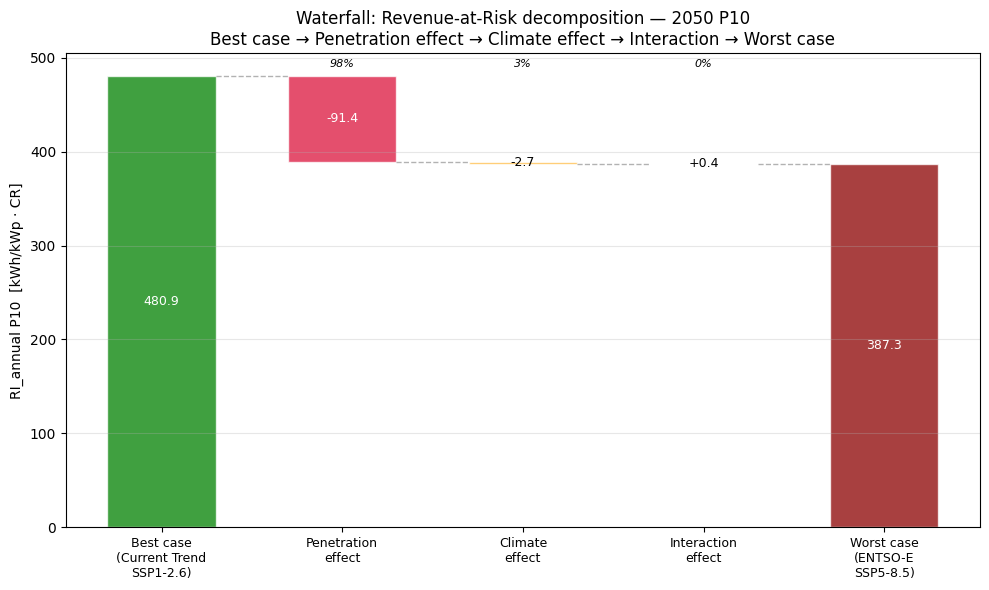


── Multi-scenario Revenue Index complete ────────────────────────
  Combinations : 9
  Saved        : risk_metrics_summary.parquet
                 ri_annual_results_multiscenario.parquet
  Reference    : (pniec, baseline)

  2050 P10 range: 480.9 (best) → 387.3 (worst)  Δ=-93.6
  Penetration drives 98% of gap
  Climate drives     3% of gap
  Interaction        0% of gap


In [16]:
# STEP 9 — Waterfall decomposition of Revenue-at-Risk (P10) in 2050
# ─────────────────────────────────────────────────────────────────────────────
 
print(f"\n── Step 9: Waterfall decomposition (2050 P10) ───────────────────")
 
# P10 values for decomposition
def get_p10(pen_key, temp_key, year=2050):
    return float(df_metrics[
        (df_metrics["pen_scenario"]==pen_key) &
        (df_metrics["temp_scenario"]==temp_key) &
        (df_metrics["year"]==year)
    ]["RI_p10"].iloc[0])
 
p10_best      = get_p10("current_trend", "ssp126")   # best case
p10_pen_shock = get_p10("entso_e",       "ssp126")   # add pen shock only
p10_clim_shock= get_p10("current_trend", "ssp585")   # add climate shock only
p10_worst     = get_p10("entso_e",       "ssp585")   # worst case
 
# decomposition
penetration_effect = p10_pen_shock - p10_best
climate_effect     = p10_clim_shock - p10_best
interaction_effect = p10_worst - p10_best - penetration_effect - climate_effect
 
print(f"  P10 best case   (Current Trend | SSP1-2.6) : {p10_best:>8.2f}")
print(f"  Penetration effect  (Current→ENTSO-E)      : {penetration_effect:>+8.2f}")
print(f"  Climate effect      (SSP126→SSP585)         : {climate_effect:>+8.2f}")
print(f"  Interaction effect  (joint)                 : {interaction_effect:>+8.2f}")
print(f"  P10 worst case  (ENTSO-E | SSP5-8.5)       : {p10_worst:>8.2f}")
print(f"  Check (should = 0): "
      f"{p10_best+penetration_effect+climate_effect+interaction_effect-p10_worst:+.6f}")
 
# waterfall chart
fig, ax = plt.subplots(figsize=(10, 6))
categories = ["Best case\n(Current Trend\nSSP1-2.6)",
              "Penetration\neffect",
              "Climate\neffect",
              "Interaction\neffect",
              "Worst case\n(ENTSO-E\nSSP5-8.5)"]
values     = [p10_best,
              penetration_effect,
              climate_effect,
              interaction_effect,
              p10_worst]
colors_wf  = ["green", "crimson", "orange", "purple", "darkred"]
running    = p10_best
 
bars_bottom = [0, p10_best, p10_best+penetration_effect,
               p10_best+penetration_effect+climate_effect, 0]
bars_height = [p10_best,
               penetration_effect,
               climate_effect,
               interaction_effect,
               p10_worst]
 
for xi, (bot, hgt, col, cat) in enumerate(
        zip(bars_bottom, bars_height, colors_wf, categories)):
    ax.bar(xi, abs(hgt), bottom=min(bot, bot+hgt),
           color=col, alpha=0.75, width=0.6, edgecolor="white")
    # connector lines
    if xi < 4:
        next_bot = bars_bottom[xi+1]
        ax.plot([xi+0.3, xi+0.7], [bot+hgt, bot+hgt],
                color="grey", lw=1.0, ls="--", alpha=0.6)
    # value annotation
    val_y = min(bot, bot+hgt) + abs(hgt)/2
    ax.text(xi, val_y, f"{hgt:+.1f}" if xi not in [0,4] else f"{abs(hgt):.1f}",
            ha="center", va="center", fontsize=9,
            color="white" if abs(hgt) > 20 else "black")
 
ax.set_xticks(range(5))
ax.set_xticklabels(categories, fontsize=9)
ax.set_ylabel("RI_annual P10  [kWh/kWp · CR]")
ax.set_title(
    f"Waterfall: Revenue-at-Risk decomposition — 2050 P10\n"
    f"Best case → Penetration effect → Climate effect → "
    f"Interaction → Worst case"
)
ax.grid(alpha=0.3, axis="y")
 
# pct annotations
total_gap = abs(p10_worst - p10_best)
if total_gap > 0:
    for xi, (val, label) in enumerate([
        (penetration_effect, "pen"),
        (climate_effect,     "clim"),
        (interaction_effect, "int"),
    ], start=1):
        pct = abs(val) / total_gap * 100
        ax.text(xi, ax.get_ylim()[1]*0.97, f"{pct:.0f}%",
                ha="center", fontsize=8, color="black",
                style="italic")
 
plt.tight_layout()
plt.show()
 
print(f"\n── Multi-scenario Revenue Index complete ────────────────────────")
print(f"  Combinations : {len(COMBINATIONS)}")
print(f"  Saved        : {out_metrics.name}")
print(f"                 {out_annual.name}")
print(f"  Reference    : ({REF_PEN}, {REF_TEMP})")
print(f"\n  2050 P10 range: {p10_best:.1f} (best) → {p10_worst:.1f} (worst)  "
      f"Δ={p10_worst-p10_best:+.1f}")
print(f"  Penetration drives {abs(penetration_effect)/total_gap*100:.0f}% of gap")
print(f"  Climate drives     {abs(climate_effect)/total_gap*100:.0f}% of gap")
print(f"  Interaction        {abs(interaction_effect)/total_gap*100:.0f}% of gap")

  Cumulative and NPV arrays computed for 9 combinations
  Reference cumulative mean : 18704.8
  Reference NPV mean        : 10132.9  (r=7%)


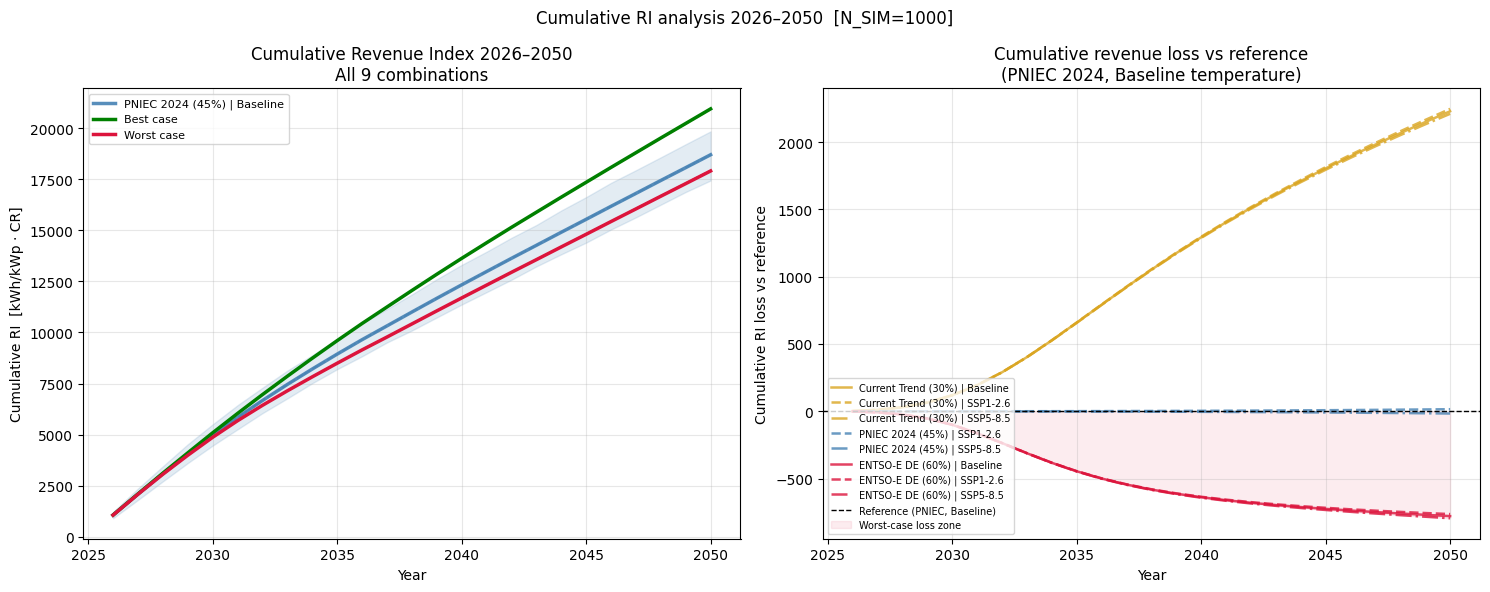


  Cumulative RI 2026–2050 (undiscounted):
  Scenario                                             mean         P10      Δ mean
  ---------------------------------------------  ----------  ----------  ----------
  Current Trend (30%) | Baseline                    20933.6     19670.7     +2228.8
  Current Trend (30%) | SSP1-2.6                    20951.4     19687.2     +2246.6
  Current Trend (30%) | SSP5-8.5                    20914.7     19653.2     +2209.9
  PNIEC 2024 (45%) | Baseline                       18704.8     17443.7        +0.0
  PNIEC 2024 (45%) | SSP1-2.6                       18720.3     17458.6       +15.5
  PNIEC 2024 (45%) | SSP5-8.5                       18688.4     17428.6       -16.4
  ENTSO-E DE (60%) | Baseline                       17926.3     16663.9      -778.5
  ENTSO-E DE (60%) | SSP1-2.6                       17941.3     16677.9      -763.5
  ENTSO-E DE (60%) | SSP5-8.5                       17910.4     16649.4      -794.4

  NPV-equivalent (r=7%):
  Curre

In [17]:
# ── compute cumulative sums before plotting ───────────────────────────────────
DISCOUNT_RATE = 0.07   # 7% WACC

cumulative = {}
npv_cum    = {}

for comb in COMBINATIONS:
    key = (comb["pen_key"], comb["temp_key"])

    # undiscounted cumulative sum per path (N_SIM,)
    cumulative[key] = RI_annual[key].sum(axis=1)

    # NPV-equivalent
    npv = np.zeros(N_SIM)
    for yi, yr in enumerate(years_unique):
        t   = yr - years_unique[0]
        npv += RI_annual[key][:, yi] / (1 + DISCOUNT_RATE) ** t
    npv_cum[key] = npv

ref_cum = cumulative[ref_key]
ref_npv = npv_cum[ref_key]

print(f"  Cumulative and NPV arrays computed for {len(COMBINATIONS)} combinations")
print(f"  Reference cumulative mean : {ref_cum.mean():.1f}")
print(f"  Reference NPV mean        : {ref_npv.mean():.1f}  (r={DISCOUNT_RATE:.0%})")

# ── cumulative fan chart ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# left: absolute cumulative RI
ax = axes[0]
for comb in COMBINATIONS:
    key   = (comb["pen_key"], comb["temp_key"])
    color = PEN_COLORS[comb["pen_key"]]
    ls    = TEMP_STYLES[comb["temp_key"]]

    # cumulative sum year by year across paths
    cum_mean = np.array([
        RI_annual[key][:, :yi+1].sum(axis=1).mean()
        for yi in range(len(years_unique))
    ])
    cum_p10  = np.array([
        np.percentile(RI_annual[key][:, :yi+1].sum(axis=1), 10)
        for yi in range(len(years_unique))
    ])
    cum_p90  = np.array([
        np.percentile(RI_annual[key][:, :yi+1].sum(axis=1), 90)
        for yi in range(len(years_unique))
    ])

    is_ref = (key == ref_key)
    lw     = 2.5 if is_ref else 1.2
    alpha  = 0.9 if is_ref else 0.5
    ax.plot(years_unique, cum_mean,
            color=color, lw=lw, ls=ls, alpha=alpha,
            label=comb["label"] if is_ref else None)
    if is_ref:
        ax.fill_between(years_unique, cum_p10, cum_p90,
                        alpha=0.15, color=color)

# overlay best and worst
for key, color, label in [
    (("current_trend","ssp126"), "green",  "Best case"),
    (("entso_e",      "ssp585"), "crimson","Worst case"),
]:
    cum_mean = np.array([
        RI_annual[key][:,:yi+1].sum(axis=1).mean()
        for yi in range(len(years_unique))
    ])
    ax.plot(years_unique, cum_mean,
            color=color, lw=2.5, ls="-", label=label)

ax.set_xlabel("Year")
ax.set_ylabel("Cumulative RI  [kWh/kWp · CR]")
ax.set_title("Cumulative Revenue Index 2026–2050\n"
             "All 9 combinations")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# right: cumulative loss vs reference
ax = axes[1]
for comb in COMBINATIONS:
    key   = (comb["pen_key"], comb["temp_key"])
    color = PEN_COLORS[comb["pen_key"]]
    ls    = TEMP_STYLES[comb["temp_key"]]
    if key == ref_key:
        continue

    cum_delta = np.array([
        RI_annual[key][:, :yi+1].sum(axis=1).mean() -
        RI_annual[ref_key][:, :yi+1].sum(axis=1).mean()
        for yi in range(len(years_unique))
    ])
    ax.plot(years_unique, cum_delta,
            color=color, lw=1.8, ls=ls, alpha=0.8,
            label=comb["label"][:35])

ax.axhline(0, color="black", lw=1.0, ls="--",
           label="Reference (PNIEC, Baseline)")
# shade the region below zero (all scenarios worse than reference)
worst_cum_delta = np.array([
    min(
        RI_annual[k][:, :yi+1].sum(axis=1).mean() -
        RI_annual[ref_key][:, :yi+1].sum(axis=1).mean()
        for c in COMBINATIONS
        for k in [(c["pen_key"], c["temp_key"])]
        if k != ref_key
    )
    for yi in range(len(years_unique))
])
ax.fill_between(years_unique,
                worst_cum_delta, 0,
                where=worst_cum_delta < 0,
                alpha=0.08, color="crimson",
                label="Worst-case loss zone")
ax.set_xlabel("Year")
ax.set_ylabel("Cumulative RI loss vs reference")
ax.set_title("Cumulative revenue loss vs reference\n"
             "(PNIEC 2024, Baseline temperature)")
ax.legend(fontsize=7, loc="lower left")
ax.grid(alpha=0.3)

plt.suptitle(
    f"Cumulative RI analysis 2026–2050  [N_SIM={N_SIM}]",
    fontsize=12
)
plt.tight_layout()
plt.show()

# ── summary statistics ────────────────────────────────────────────────────────
print(f"\n  Cumulative RI 2026–2050 (undiscounted):")
print(f"  {'Scenario':<45}  {'mean':>10}  {'P10':>10}  {'Δ mean':>10}")
print(f"  {'-'*45}  {'-'*10}  {'-'*10}  {'-'*10}")
for comb in COMBINATIONS:
    key = (comb["pen_key"], comb["temp_key"])
    cum = cumulative[key]
    print(f"  {comb['label'][:45]:<45}  "
          f"{cum.mean():>10.1f}  "
          f"{np.percentile(cum,10):>10.1f}  "
          f"{cum.mean()-ref_cum.mean():>+10.1f}")

print(f"\n  NPV-equivalent (r={DISCOUNT_RATE:.0%}):")
for comb in COMBINATIONS:
    key = (comb["pen_key"], comb["temp_key"])
    npv = npv_cum[key]
    print(f"  {comb['label'][:45]:<45}  "
          f"NPV={npv.mean():>8.1f}  "
          f"Δ={npv.mean()-ref_npv.mean():>+8.1f}")


── VaR and CVaR analysis — 2050 ─────────────────────────────

  Scenario                                 Mean       Std    VaR10%    CVaR10%     VaR5%    CVaR5%     VaR1%    CVaR1%
  -----------------------------------  --------  --------  --------  ---------  --------  --------  --------  --------
  Reference (PNIEC, Baseline)            631.71    185.94    397.93     282.09    316.48    206.82    134.48     61.08
  Best case (Current Trend, SSP1-2.6)    714.05    186.22    480.86     364.26    399.63    289.00    214.23    143.02
  Worst case (ENTSO-E, SSP5-8.5)         620.37    185.42    387.27     271.67    305.87    196.61    124.76     51.28

  Loss vs reference mean  (ref mean = 631.71):
  Scenario                             VaR10 loss   CVaR10 loss   VaR5 loss  CVaR5 loss
  -----------------------------------  ----------  ------------  ----------  ----------
  Reference (PNIEC, Baseline)             +233.77       +349.62     +315.23     +424.89
  Best case (Current Trend, S

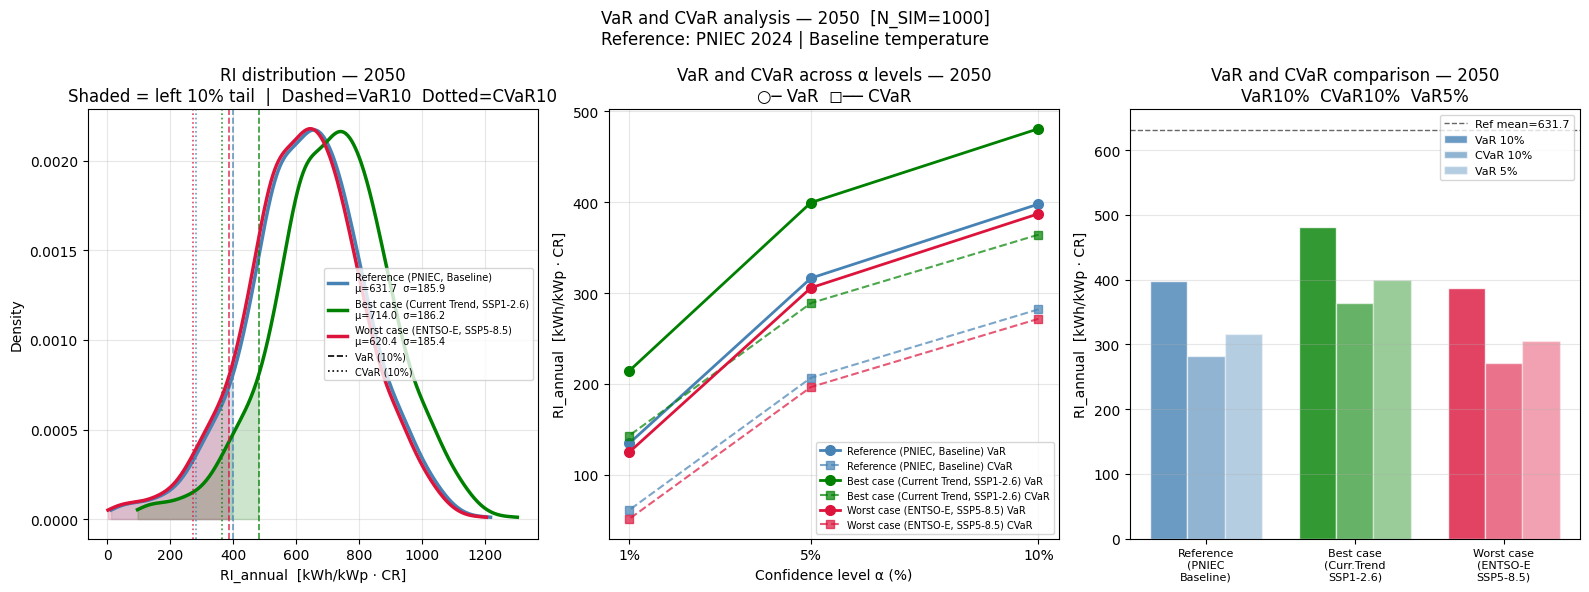

In [18]:
# ── VaR and CVaR analysis — 2050 distribution ────────────────────────────────
# Three scenarios: reference (PNIEC, Baseline), best (Current Trend, SSP1-2.6),
# worst (ENTSO-E, SSP5-8.5)
#
# VaR(α)  = -P(α) of the annual RI distribution
#           the revenue level NOT exceeded with probability α
# CVaR(α) = -E[RI | RI ≤ P(α)]
#           expected revenue in the worst α% of outcomes
# Here expressed as POSITIVE losses relative to the mean (downside deviation)

YEAR_ANALYSIS = 2050
yi_2050       = list(years_unique).index(YEAR_ANALYSIS)
ALPHA_LEVELS  = [0.10, 0.05, 0.01]   # 10%, 5%, 1% tail

scenarios_analysis = {
    "Reference\n(PNIEC, Baseline)":       ref_key,
    "Best case\n(Current Trend, SSP1-2.6)": ("current_trend", "ssp126"),
    "Worst case\n(ENTSO-E, SSP5-8.5)":      ("entso_e",       "ssp585"),
}
colors_analysis = {
    "Reference\n(PNIEC, Baseline)":         "steelblue",
    "Best case\n(Current Trend, SSP1-2.6)": "green",
    "Worst case\n(ENTSO-E, SSP5-8.5)":      "crimson",
}

# ── compute VaR and CVaR ──────────────────────────────────────────────────────
results_risk = {}

print(f"\n── VaR and CVaR analysis — {YEAR_ANALYSIS} ─────────────────────────────")
print(f"\n  {'Scenario':<35}  {'Mean':>8}  {'Std':>8}  "
      f"{'VaR10%':>8}  {'CVaR10%':>9}  "
      f"{'VaR5%':>8}  {'CVaR5%':>8}  "
      f"{'VaR1%':>8}  {'CVaR1%':>8}")
print(f"  {'-'*35}  {'-'*8}  {'-'*8}  "
      f"{'-'*8}  {'-'*9}  "
      f"{'-'*8}  {'-'*8}  "
      f"{'-'*8}  {'-'*8}")

for label, key in scenarios_analysis.items():
    ri  = RI_annual[key][:, yi_2050]
    res = {"mean": ri.mean(), "std": ri.std(), "paths": ri}

    for alpha in ALPHA_LEVELS:
        var_val  = float(np.percentile(ri, alpha * 100))
        cvar_val = float(ri[ri <= var_val].mean())
        res[f"VaR_{alpha}"]  = var_val
        res[f"CVaR_{alpha}"] = cvar_val

    results_risk[label] = res

    # print one row
    clean = label.replace("\n", " ")
    print(f"  {clean:<35}  "
          f"{res['mean']:>8.2f}  "
          f"{res['std']:>8.2f}  "
          f"{res['VaR_0.1']:>8.2f}  "
          f"{res['CVaR_0.1']:>9.2f}  "
          f"{res['VaR_0.05']:>8.2f}  "
          f"{res['CVaR_0.05']:>8.2f}  "
          f"{res['VaR_0.01']:>8.2f}  "
          f"{res['CVaR_0.01']:>8.2f}")

# ── VaR and CVaR loss relative to reference mean ─────────────────────────────
ref_mean = results_risk[list(scenarios_analysis.keys())[0]]["mean"]
print(f"\n  Loss vs reference mean  (ref mean = {ref_mean:.2f}):")
print(f"  {'Scenario':<35}  {'VaR10 loss':>10}  {'CVaR10 loss':>12}  "
      f"{'VaR5 loss':>10}  {'CVaR5 loss':>10}")
print(f"  {'-'*35}  {'-'*10}  {'-'*12}  {'-'*10}  {'-'*10}")
for label, res in results_risk.items():
    clean = label.replace("\n", " ")
    print(f"  {clean:<35}  "
          f"{ref_mean - res['VaR_0.1']:>+10.2f}  "
          f"{ref_mean - res['CVaR_0.1']:>+12.2f}  "
          f"{ref_mean - res['VaR_0.05']:>+10.2f}  "
          f"{ref_mean - res['CVaR_0.05']:>+10.2f}")

# ── plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# ── left: distribution overlay with VaR and CVaR markers ─────────────────────
ax = axes[0]
for label, res in results_risk.items():
    ri    = res["paths"]
    color = colors_analysis[label]
    x_kde = np.linspace(ri.min() - 10, ri.max() + 10, 400)
    kde   = gaussian_kde(ri)
    ax.plot(x_kde, kde(x_kde), color=color, lw=2.5,
            label=label.replace("\n"," ") +
                  f"\nμ={ri.mean():.1f}  σ={ri.std():.1f}")
    ax.fill_between(x_kde, kde(x_kde),
                    where=x_kde <= res["VaR_0.1"],
                    alpha=0.20, color=color)

    # VaR10 and CVaR10 markers
    ax.axvline(res["VaR_0.1"], color=color, lw=1.2, ls="--", alpha=0.8)
    ax.axvline(res["CVaR_0.1"], color=color, lw=1.2, ls=":", alpha=0.8)

# legend for line styles
ax.plot([], [], "k--", lw=1.2, label="VaR (10%)")
ax.plot([], [], "k:",  lw=1.2, label="CVaR (10%)")
ax.set_xlabel(f"RI_annual  [kWh/kWp · CR]")
ax.set_ylabel("Density")
ax.set_title(f"RI distribution — {YEAR_ANALYSIS}\n"
             f"Shaded = left 10% tail  |  Dashed=VaR10  Dotted=CVaR10")
ax.legend(fontsize=7)
ax.grid(alpha=0.3)

# ── middle: VaR across alpha levels ──────────────────────────────────────────
ax = axes[1]
alpha_pct = [a * 100 for a in ALPHA_LEVELS]
for label, res in results_risk.items():
    color  = colors_analysis[label]
    var_vals  = [res[f"VaR_{a}"]  for a in ALPHA_LEVELS]
    cvar_vals = [res[f"CVaR_{a}"] for a in ALPHA_LEVELS]
    ax.plot(alpha_pct, var_vals,  "o-", color=color, lw=2.0, ms=7,
            label=label.replace("\n"," ") + " VaR")
    ax.plot(alpha_pct, cvar_vals, "s--", color=color, lw=1.5, ms=6,
            alpha=0.7, label=label.replace("\n"," ") + " CVaR")

ax.set_xlabel("Confidence level α (%)")
ax.set_ylabel("RI_annual  [kWh/kWp · CR]")
ax.set_title(f"VaR and CVaR across α levels — {YEAR_ANALYSIS}\n"
             f"○─ VaR  ◻── CVaR")
ax.set_xticks(alpha_pct)
ax.set_xticklabels([f"{a:.0f}%" for a in alpha_pct])
ax.legend(fontsize=7)
ax.grid(alpha=0.3)

# ── right: CVaR10 comparison bar chart ───────────────────────────────────────
ax = axes[2]
labels_short = ["Reference\n(PNIEC\nBaseline)",
                "Best case\n(Curr.Trend\nSSP1-2.6)",
                "Worst case\n(ENTSO-E\nSSP5-8.5)"]
x        = np.arange(3)
width    = 0.25
metrics  = [("VaR 10%",  "VaR_0.1",  0.8),
             ("CVaR 10%", "CVaR_0.1", 0.6),
             ("VaR 5%",   "VaR_0.05", 0.4)]

for mi, (metric_label, metric_key, alpha_bar) in enumerate(metrics):
    vals = [list(results_risk.values())[si][metric_key]
            for si in range(3)]
    colors_bar = [list(colors_analysis.values())[si]
                  for si in range(3)]
    bars = ax.bar(x + mi*width - width, vals,
                  width=width,
                  color=colors_bar,
                  alpha=alpha_bar,
                  label=metric_label,
                  edgecolor="white")

ax.axhline(ref_mean, color="black", lw=1.0, ls="--",
           alpha=0.6, label=f"Ref mean={ref_mean:.1f}")
ax.set_xticks(x)
ax.set_xticklabels(labels_short, fontsize=8)
ax.set_ylabel("RI_annual  [kWh/kWp · CR]")
ax.set_title(f"VaR and CVaR comparison — {YEAR_ANALYSIS}\n"
             f"VaR10%  CVaR10%  VaR5%")
ax.legend(fontsize=8)
ax.grid(alpha=0.3, axis="y")

plt.suptitle(
    f"VaR and CVaR analysis — {YEAR_ANALYSIS}  [N_SIM={N_SIM}]\n"
    f"Reference: PNIEC 2024 | Baseline temperature",
    fontsize=12
)
plt.tight_layout()
plt.show()

# Variance decomposition

In [19]:
# ── Approach 1: log-variance decomposition ────────────────────────────────────
YEAR_DECOMP = 2050
yi = list(years_unique).index(YEAR_DECOMP)

for label, key in scenarios_analysis.items():
    ri   = RI_annual[key][:, yi]
    p    = P_annual[key][:, yi]
    cr   = CR_annual[key][:, yi]

    # log-variance decomposition (joint mask: all three positive)
    _mask  = (ri > 0) & (p > 0) & (cr > 0)
    log_ri = np.log(ri[_mask])
    log_p  = np.log(p[_mask])
    log_cr = np.log(cr[_mask])

    var_log_p  = np.var(log_p,  ddof=1)
    var_log_cr = np.var(log_cr, ddof=1)
    cov_p_cr   = np.cov(log_p, log_cr)[0, 1]
    var_log_ri = np.var(log_ri, ddof=1)

    # percentage attributions
    pct_p    = var_log_p  / var_log_ri * 100
    pct_cr   = var_log_cr / var_log_ri * 100
    pct_cov  = 2 * cov_p_cr / var_log_ri * 100

    print(f"\n  {label.replace(chr(10),' ')}")
    print(f"    Var[log P]   = {var_log_p:.5f}  ({pct_p:.1f}%)")
    print(f"    Var[log CR]  = {var_log_cr:.5f}  ({pct_cr:.1f}%)")
    print(f"    2·Cov(P,CR)  = {2*cov_p_cr:.5f}  ({pct_cov:.1f}%)")
    print(f"    Total        = {var_log_ri:.5f}  (100%)")


  Reference (PNIEC, Baseline)
    Var[log P]   = 0.00119  (0.7%)
    Var[log CR]  = 0.09230  (56.4%)
    2·Cov(P,CR)  = -0.00518  (-3.2%)
    Total        = 0.16357  (100%)

  Best case (Current Trend, SSP1-2.6)
    Var[log P]   = 0.00119  (1.2%)
    Var[log CR]  = 0.06774  (67.6%)
    2·Cov(P,CR)  = -0.00447  (-4.5%)
    Total        = 0.10016  (100%)

  Worst case (ENTSO-E, SSP5-8.5)
    Var[log P]   = 0.00119  (0.7%)
    Var[log CR]  = 0.09636  (52.9%)
    2·Cov(P,CR)  = -0.00528  (-2.9%)
    Total        = 0.18229  (100%)


# Analysing distribution results

In [20]:
import pickle, json
import numpy as np
import pandas as pd
from pathlib import Path

# =============================================================================
# Historical modelled variables reconstruction (2005-2025)
# Mirrors the simulation pipeline applied to the single historical realisation
#
# GHI  : ARMA pipeline  →  Kt_fitted × GHI_cs
# Temp : ARCH model     →  arch_predicted
# CR   : CR model       →  CR_seasonal_full
# P    : (GHI / G_STC) × (1 + γ(T_eff − T_STC)) × PR
# RI   : P × CR
# =============================================================================

_model_dir = Path("../../Code/Models/GHI - KT")

# --- GHI model artefacts -----------------------------------------------------
with open(_model_dir / "ghi_arma_result.pkl", "rb") as f:
    _arma = pickle.load(f)

with open(_model_dir / "ghi_seasonal_coeffs.pkl", "rb") as f:
    _sc = pickle.load(f)          # [a0, a1, a2]

with open(_model_dir / "model_meta.json") as f:
    _meta = json.load(f)

_alpha = _meta["logit_transform"]["alpha"]
_beta  = _meta["logit_transform"]["beta"]
_a0, _a1, _a2 = _sc[0], _sc[1], _sc[2]

# --- load historical physical data -------------------------------------------
_df_cr_h = pd.read_parquet(
    Path("../../Data/Modelled/df_cr_modelled.parquet"),
    columns=["date", "year", "capture_rate", "CR_seasonal_full"]
)
_df_cr_h["date"] = pd.to_datetime(_df_cr_h["date"])
_df_sol_h = pd.read_parquet(
    Path("../../Data/Modelled/df_solar_modelled.parquet"),
).reset_index().rename(columns={"GHI_obs": "ghi_sum", "GHI_cs": "ghi_cs_sum"})
_df_sol_h["date"] = pd.to_datetime(_df_sol_h["date"])
_df_cr_h = _df_cr_h.merge(_df_sol_h[["date", "ghi_sum", "ghi_cs_sum"]], on="date", how="left")

_df_tmp_h = pd.read_parquet(
    Path("../../Data/Modelled/df_temperature_modeled.parquet"),
    columns=["date", "t2m_mean", "ar1_resid"]
)
_df_tmp_h["date"] = pd.to_datetime(_df_tmp_h["date"])

_df_h = _df_cr_h.merge(_df_tmp_h, on="date").sort_values("date").reset_index(drop=True)

# --- reconstruct modelled GHI ------------------------------------------------
# Pipeline: Kt_obs → logit → deseasonalise → ARMA fit
#           ARMA fitted → add seasonal mean → inverse logit → Kt_fitted → GHI

_doy   = _df_h["date"].dt.dayofyear.values
_t_rad = 2 * np.pi * _doy / 365.0
_Y_bar = _a0 + _a1 * np.cos(_t_rad) + _a2 * np.sin(_t_rad)

# ARMA fitted values aligned by date
_fv = _arma.fittedvalues.rename("Ytilde_fitted")
_fv.index = pd.to_datetime(_fv.index)
_df_h = _df_h.merge(_fv.reset_index().rename(columns={"index": "date"}), on="date", how="left")

# Yt_fitted = Ytilde_fitted + Y_bar  →  invert logit  →  Kt_fitted
_Yt_fit   = _df_h["Ytilde_fitted"].values + _Y_bar
_Xp_fit   = 1.0 / (1.0 + np.exp(-_Yt_fit))
_Kt_fit   = (_Xp_fit - _alpha) / _beta
_Kt_fit   = np.clip(_Kt_fit, 0.0, 1.0)

_df_h["GHI_actual"]  = _df_h["ghi_sum"].values
_df_h["GHI_modelled"] = _Kt_fit * _df_h["ghi_cs_sum"].values

# --- modelled temperature ----------------------------------------------------
# arch_predicted is in STL-residual space; to get temperature-level fitted value:
#   T_modelled = STL_trend + STL_seasonal + arch_predicted
#              = t2m_mean - STL_resid + arch_predicted
#              = t2m_mean - arch_resid   (since STL_resid = arch_resid + arch_predicted)
_df_h["T_actual"]   = _df_h["t2m_mean"].values
_df_h["T_modelled"] = (_df_h["t2m_mean"] - _df_h["ar1_resid"]).values

# --- modelled CR -------------------------------------------------------------
_df_h["CR_actual"]   = _df_h["capture_rate"].values
_df_h["CR_modelled"] = _df_h["CR_seasonal_full"].values

# --- reconstruct P and RI (actual and modelled) ------------------------------
_uplift = float(np.mean(list(uplift_by_doy.values())))

def _compute_P(ghi, t2m):
    T_eff = t2m + _uplift
    return (ghi / G_STC) * (1 + GAMMA * (T_eff - T_STC)) * PR

_df_h["P_actual"]   = _compute_P(_df_h["GHI_actual"].values,   _df_h["T_actual"].values)
_df_h["P_modelled"] = _compute_P(_df_h["GHI_modelled"].values, _df_h["T_modelled"].values)

_df_h["RI_actual"]   = _df_h["P_actual"].values   * _df_h["CR_actual"].values
_df_h["RI_modelled"] = _df_h["P_modelled"].values * _df_h["CR_modelled"].values

# --- final dataframe ---------------------------------------------------------
df_hist_reconstructed = _df_h[[
    "date", "year",
    "GHI_actual", "GHI_modelled",
    "T_actual",   "T_modelled",
    "CR_actual",  "CR_modelled",
    "P_actual",   "P_modelled",
    "RI_actual",  "RI_modelled",
]].copy()

# summary
print(f"  df_hist_reconstructed: {len(df_hist_reconstructed):,} rows  "
      f"({int(df_hist_reconstructed['year'].min())}–{int(df_hist_reconstructed['year'].max())})")
print()
_vars = [("GHI", "GHI_actual", "GHI_modelled"),
         ("T",   "T_actual",   "T_modelled"),
         ("CR",  "CR_actual",  "CR_modelled"),
         ("P",   "P_actual",   "P_modelled"),
         ("RI",  "RI_actual",  "RI_modelled")]

print(f"  {'Var':<5}  {'Mean actual':>13}  {'Mean modelled':>13}  {'Corr':>7}  {'NaN mod':>8}")
print(f"  {'-'*5}  {'-'*13}  {'-'*13}  {'-'*7}  {'-'*8}")
for tag, col_a, col_m in _vars:
    _a  = df_hist_reconstructed[col_a].values
    _m  = df_hist_reconstructed[col_m].values
    _ok = np.isfinite(_a) & np.isfinite(_m)
    _c  = float(np.corrcoef(_a[_ok], _m[_ok])[0, 1]) if _ok.sum() > 2 else np.nan
    _nn = int((~np.isfinite(_m)).sum())
    print(f"  {tag:<5}  {np.nanmean(_a):>13.4f}  {np.nanmean(_m):>13.4f}  {_c:>7.4f}  {_nn:>8d}")
# --- filtered RI arrays for distribution comparison -------------------------
_hist_ghi_ok = df_hist_reconstructed["GHI_actual"] >= 50.0
_ri_hist_d   = df_hist_reconstructed.loc[_hist_ghi_ok, "RI_actual"].values
_ri_model_d  = df_hist_reconstructed.loc[_hist_ghi_ok, "RI_modelled"].values
print(f"  _ri_hist_d:  n={len(_ri_hist_d):,}")
print(f"  _ri_model_d: n={len(_ri_model_d):,}")

  df_hist_reconstructed: 7,670 rows  (2005–2025)

  Var      Mean actual  Mean modelled     Corr   NaN mod
  -----  -------------  -------------  -------  --------
  GHI        4085.1976       764.3123  -0.1498         0
  T            13.2999        13.3002   0.9854         0
  CR            1.0012         1.0012   0.6582         0
  P             3.1626         0.6037  -0.1635         0
  RI            3.1869         0.6037  -0.1371         0
  _ri_hist_d:  n=7,670
  _ri_model_d: n=7,670


  KS test  : stat=0.7083   p=0.0000
  MW test  : stat=54402448   p=0.0000

  Metric                  Historical        Modelled        Diff
  ------------------  --------------  --------------  ----------
  Mean                        3.1869          0.6037     -2.5832
  Std                         1.9081          0.4954     -1.4127
  P5                          0.5249          0.0675     -0.4574
  P50                         2.9835          0.4925     -2.4910
  P95                         6.3247          1.5744     -4.7503
  Skew                        0.2764          1.4019     +1.1255
  Kurt                       -1.0802          2.6878     +3.7680


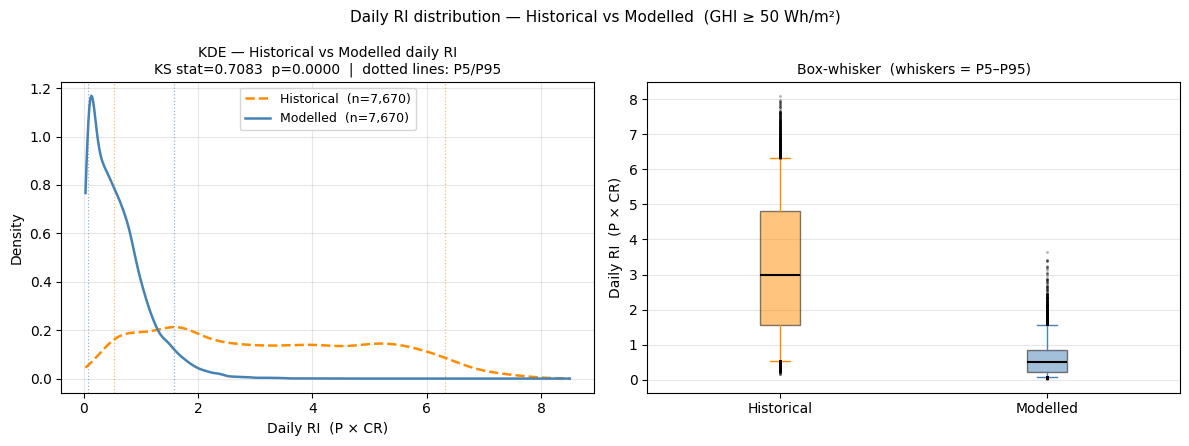

In [21]:
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, ks_2samp, mannwhitneyu

# =============================================================================
# Distribution comparison — historical vs modelled daily RI
# Reuses _ri_hist_d and _ri_model_d from the previous cell
# =============================================================================

_series_dist = [
    (_ri_hist_d,  "darkorange", "--", f"Historical  (n={len(_ri_hist_d):,})"),
    (_ri_model_d, "steelblue",  "-",  f"Modelled  (n={len(_ri_model_d):,})"),
]

# --- distribution tests ------------------------------------------------------
ks_stat, ks_p   = ks_2samp(_ri_hist_d, _ri_model_d)
mw_stat, mw_p   = mannwhitneyu(_ri_hist_d, _ri_model_d, alternative="two-sided")

print(f"  KS test  : stat={ks_stat:.4f}   p={ks_p:.4f}")
print(f"  MW test  : stat={mw_stat:.0f}   p={mw_p:.4f}")
print()
print(f"  {'Metric':<18}  {'Historical':>14}  {'Modelled':>14}  {'Diff':>10}")
print(f"  {'-'*18}  {'-'*14}  {'-'*14}  {'-'*10}")
for label, arr in [("Historical", _ri_hist_d), ("Modelled", _ri_model_d)]:
    pass  # computed below in table
_stats = {}
for name, arr in [("Historical", _ri_hist_d), ("Modelled", _ri_model_d)]:
    from scipy.stats import skew, kurtosis
    _stats[name] = {
        "Mean":   arr.mean(),
        "Std":    arr.std(ddof=1),
        "P5":     float(np.percentile(arr,  5)),
        "P50":    float(np.percentile(arr, 50)),
        "P95":    float(np.percentile(arr, 95)),
        "Skew":   float(skew(arr)),
        "Kurt":   float(kurtosis(arr)),
    }
for metric in ["Mean", "Std", "P5", "P50", "P95", "Skew", "Kurt"]:
    h = _stats["Historical"][metric]
    m = _stats["Modelled"][metric]
    print(f"  {metric:<18}  {h:>14.4f}  {m:>14.4f}  {m-h:>+10.4f}")

# --- plot --------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# KDE
_x_grid = np.linspace(
    min(_ri_hist_d.min(), _ri_model_d.min()) * 0.95,
    max(_ri_hist_d.max(), _ri_model_d.max()) * 1.05,
    500
)
for arr, color, ls, label in _series_dist:
    kde = gaussian_kde(arr, bw_method="scott")
    ax1.plot(_x_grid, kde(_x_grid), color=color, ls=ls, lw=1.8, label=label)
    _p5, _p95 = np.percentile(arr, [5, 95])
    ax1.axvline(_p5,  color=color, ls=":", lw=0.9, alpha=0.6)
    ax1.axvline(_p95, color=color, ls=":", lw=0.9, alpha=0.6)

ax1.set_xlabel("Daily RI  (P × CR)", fontsize=10)
ax1.set_ylabel("Density", fontsize=10)
ax1.set_title(
    f"KDE — Historical vs Modelled daily RI\n"
    f"KS stat={ks_stat:.4f}  p={ks_p:.4f}  |  dotted lines: P5/P95",
    fontsize=10
)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Box-whisker
_bx = ax2.boxplot(
    [_ri_hist_d, _ri_model_d],
    labels=["Historical", "Modelled"],
    patch_artist=True,
    whis=[5, 95],
    medianprops=dict(color="black", lw=1.5),
    flierprops=dict(marker=".", ms=2, alpha=0.3),
)
for patch, color in zip(_bx["boxes"], ["darkorange", "steelblue"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.5)
for element in ["whiskers", "caps"]:
    for item, color in zip(
        [_bx[element][i] for i in range(len(_bx[element]))],
        ["darkorange"]*2 + ["steelblue"]*2
    ):
        item.set_color(color)

ax2.set_ylabel("Daily RI  (P × CR)", fontsize=10)
ax2.set_title("Box-whisker  (whiskers = P5–P95)", fontsize=10)
ax2.grid(True, alpha=0.3, axis="y")

fig.suptitle("Daily RI distribution — Historical vs Modelled  (GHI ≥ 50 Wh/m²)", fontsize=11)
fig.tight_layout()
plt.show()


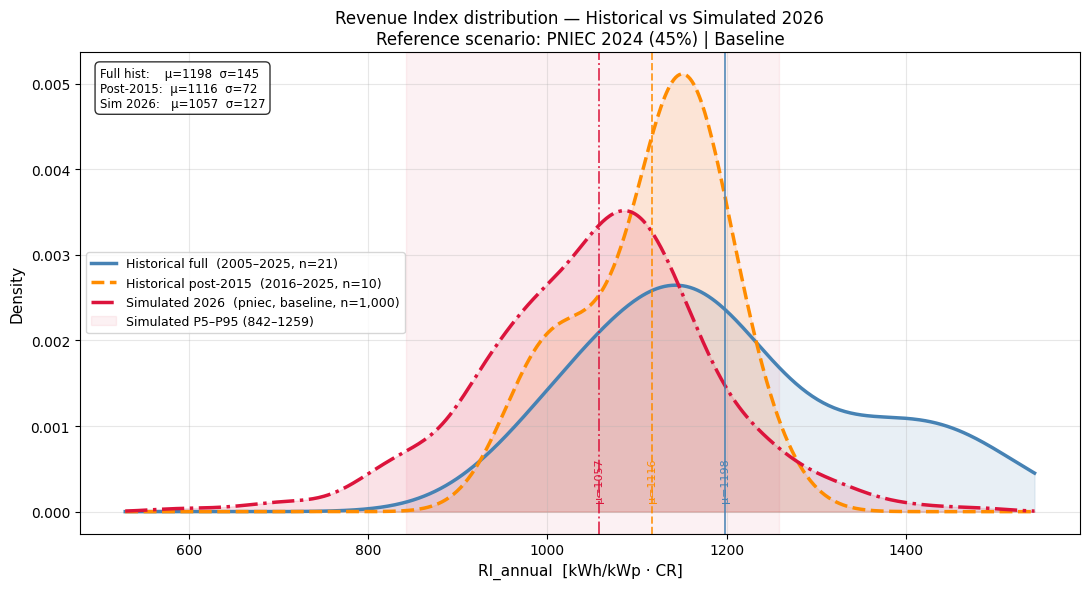


  Full hist   : μ=1197.8  σ=145.0  range=[986, 1492]
  Post-2015   : μ=1116.3  σ=72.1  range=[986, 1224]
  Sim 2026    : μ=1057.1  σ=127.3  P5=842.0  P95=1258.7


In [22]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde, t as t_dist

# ── configuration ─────────────────────────────────────────────────────────────
POST_YEAR  = 2015   # "post-2015" structural break (change as needed)
SIM_YEAR   = 2026
SIM_PEN    = REF_PEN    # "pniec"
SIM_TEMP   = REF_TEMP   # "baseline"

# ── data slices ───────────────────────────────────────────────────────────────
# load df_hist if not already in scope
_hist_path = data_results / "ri_annual_results_hist.parquet"
if "df_hist" not in dir() or not isinstance(df_hist, pd.DataFrame):
    df_hist = pd.read_parquet(_hist_path)

ri_full   = df_hist["RI_annual"].dropna().values
ri_post   = df_hist.loc[df_hist["year"] > POST_YEAR, "RI_annual"].dropna().values
ri_sim    = df_annual.loc[
    (df_annual["pen_scenario"]  == SIM_PEN)  &
    (df_annual["temp_scenario"] == SIM_TEMP) &
    (df_annual["year"]          == SIM_YEAR),
    "RI_annual"
].values

# ── KDE curves ────────────────────────────────────────────────────────────────
x_min = min(ri_full.min(), ri_sim.min()) - 50
x_max = max(ri_full.max(), ri_sim.max()) + 50
x_grid = np.linspace(x_min, x_max, 500)

kde_full = gaussian_kde(ri_full,  bw_method="scott")
kde_post = gaussian_kde(ri_post,  bw_method="scott")
kde_sim  = gaussian_kde(ri_sim,   bw_method="scott")

# ── plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(x_grid, kde_full(x_grid), color="steelblue",  lw=2.5,
        label=f"Historical full  (2005–2025, n={len(ri_full)})")
ax.fill_between(x_grid, kde_full(x_grid), alpha=0.12, color="steelblue")

ax.plot(x_grid, kde_post(x_grid), color="darkorange", lw=2.5, ls="--",
        label=f"Historical post-{POST_YEAR}  ({POST_YEAR+1}–2025, n={len(ri_post)})")
ax.fill_between(x_grid, kde_post(x_grid), alpha=0.12, color="darkorange")

ax.plot(x_grid, kde_sim(x_grid),  color="crimson",    lw=2.5, ls="-.",
        label=f"Simulated {SIM_YEAR}  ({SIM_PEN}, {SIM_TEMP}, n={len(ri_sim):,})")
ax.fill_between(x_grid, kde_sim(x_grid),  alpha=0.12, color="crimson")

# mean vertical lines
for ri, color, ls in [
    (ri_full, "steelblue",  "-"),
    (ri_post, "darkorange", "--"),
    (ri_sim,  "crimson",    "-."),
]:
    ax.axvline(ri.mean(), color=color, lw=1.4, ls=ls, alpha=0.8)
    ax.text(ri.mean(), ax.get_ylim()[1] * 0.02,
            f"μ={ri.mean():.0f}", color=color, fontsize=8,
            ha="center", va="bottom", rotation=90)

# percentile markers for simulated
p5_sim  = float(np.percentile(ri_sim, 5))
p95_sim = float(np.percentile(ri_sim, 95))
ax.axvspan(p5_sim, p95_sim, alpha=0.06, color="crimson",
           label=f"Simulated P5–P95 ({p5_sim:.0f}–{p95_sim:.0f})")

ax.set_xlabel("RI_annual  [kWh/kWp · CR]", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title(
    f"Revenue Index distribution — Historical vs Simulated {SIM_YEAR}\n"
    f"Reference scenario: {PEN_LABELS[SIM_PEN]} | {TEMP_LABELS[SIM_TEMP]}",
    fontsize=12
)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# stats box
_stats = (
    f"Full hist:    μ={ri_full.mean():.0f}  σ={ri_full.std():.0f}\n"
    f"Post-{POST_YEAR}:  μ={ri_post.mean():.0f}  σ={ri_post.std():.0f}\n"
    f"Sim {SIM_YEAR}:   μ={ri_sim.mean():.0f}  σ={ri_sim.std():.0f}"
)
ax.text(0.02, 0.97, _stats, transform=ax.transAxes,
        fontsize=8.5, va="top", ha="left",
        bbox=dict(boxstyle="round,pad=0.4", fc="white", alpha=0.8))

plt.tight_layout()
plt.show()

print(f"\n  Full hist   : μ={ri_full.mean():.1f}  σ={ri_full.std():.1f}  "
      f"range=[{ri_full.min():.0f}, {ri_full.max():.0f}]")
print(f"  Post-{POST_YEAR}   : μ={ri_post.mean():.1f}  σ={ri_post.std():.1f}  "
      f"range=[{ri_post.min():.0f}, {ri_post.max():.0f}]")
print(f"  Sim {SIM_YEAR}    : μ={ri_sim.mean():.1f}  σ={ri_sim.std():.1f}  "
      f"P5={p5_sim:.1f}  P95={p95_sim:.1f}")

  Historical post-2015 : n=3,653  μ=3.692  σ=2.282
  Historical post-2021 : n=1,461  μ=2.883  σ=1.684
  Sim 2026 [current_trend]: n=365,000  μ=2.843  σ=2.504  (pen÷=1.022)


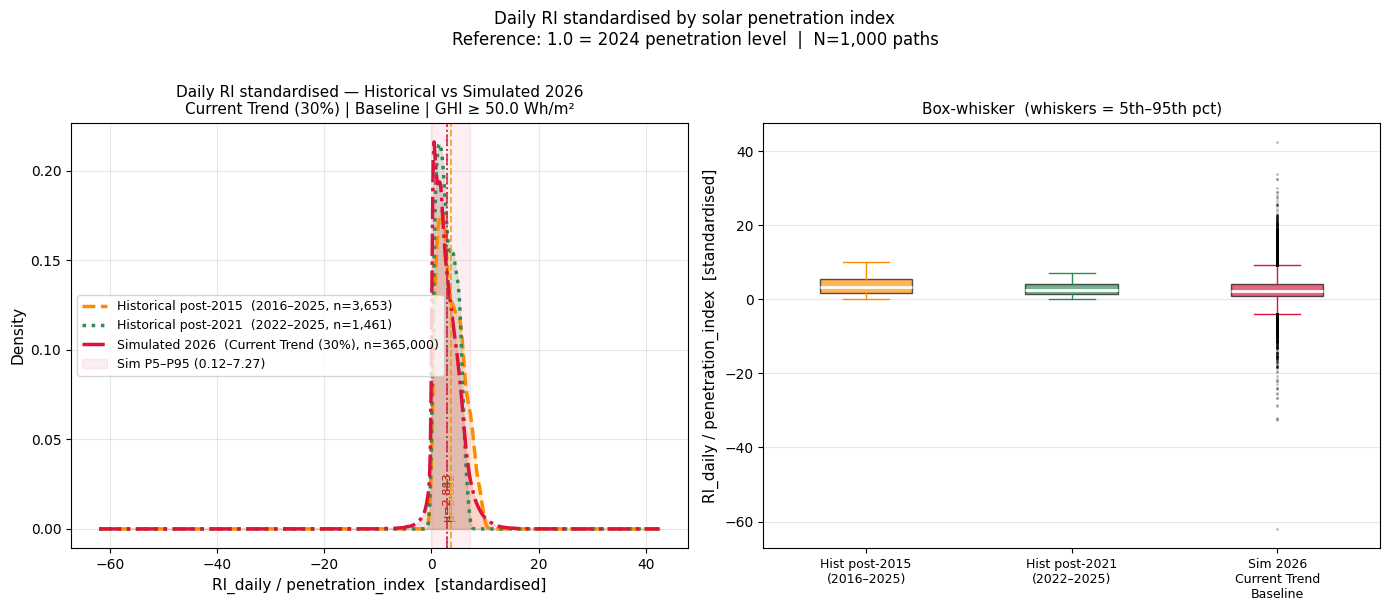

In [23]:
# daily RI distribution (historical vs simulated) 

# ── configuration ─────────────────────────────────────────────────────────────
POST_YEAR_1     = 2015
POST_YEAR_2     = 2021
SIM_YEAR_DAILY  = 2026
SIM_PEN_DAILY   = "current_trend"
SIM_TEMP_DAILY  = "baseline"
MIN_GHI         = 50.0

PEN_COL = {"current_trend": "pen_current_trend",
           "pniec":         "pen_pniec",
           "entso_e":       "pen_entso_e"}

# ── 1. HISTORICAL DAILY RI ────────────────────────────────────────────────────
df_cr_d  = pd.read_parquet(
    Path("../../Data/Modelled/df_cr_modelled.parquet"),
    columns=["date","year","capture_rate","penetration_index"]
)
df_sol_d = pd.read_parquet(
    Path("../../Data/Modelled/df_solar_modelled.parquet"),
).reset_index()[["date","GHI_obs"]].rename(columns={"GHI_obs": "ghi_sum"})
df_tmp_d = pd.read_parquet(
    Path("../../Data/Modelled/df_temperature_modeled.parquet"),
    columns=["date","t2m_mean"]
)
df_cr_d["date"]  = pd.to_datetime(df_cr_d["date"])
df_sol_d["date"] = pd.to_datetime(df_sol_d["date"])
df_tmp_d["date"] = pd.to_datetime(df_tmp_d["date"])

df_daily_h = df_cr_d.merge(df_sol_d, on="date", how="left").merge(df_tmp_d, on="date", how="inner")

_T_eff_h = df_daily_h["t2m_mean"] + float(np.mean(list(uplift_by_doy.values())))
df_daily_h["P_daily"]  = (df_daily_h["ghi_sum"] / G_STC) * \
                          (1 + GAMMA * (_T_eff_h - T_STC)) * PR
df_daily_h["RI_daily"] = df_daily_h["P_daily"] * df_daily_h["capture_rate"]
df_daily_h["RI_std"]   = df_daily_h["RI_daily"] / df_daily_h["penetration_index"]
df_daily_h = df_daily_h[df_daily_h["ghi_sum"] >= MIN_GHI].copy()

ri_hist_post1 = df_daily_h.loc[df_daily_h["year"] > POST_YEAR_1, "RI_std"].values
ri_hist_post2 = df_daily_h.loc[df_daily_h["year"] > POST_YEAR_2, "RI_std"].values

# ── 2. SIMULATED 2026 — current_trend + baseline ──────────────────────────────
df_pen = pd.read_parquet(
    Path("../../Data/Cleaned/df_penetration_scenarios.parquet"),
    columns=["date", PEN_COL[SIM_PEN_DAILY]]
)
df_pen["date"] = pd.to_datetime(df_pen["date"])
_pen_vals  = df_pen[df_pen["date"].dt.year == SIM_YEAR_DAILY].reset_index(drop=True)[PEN_COL[SIM_PEN_DAILY]].values

_mask_2026 = years_arr == SIM_YEAR_DAILY
_RI_2d     = P_temp[SIM_TEMP_DAILY][:, _mask_2026] * CR_sim_pen[SIM_PEN_DAILY][:, _mask_2026]
_RI_std    = _RI_2d / _pen_vals[np.newaxis, :]
_active    = GHI_sim[:, _mask_2026] >= MIN_GHI
ri_sim_d   = _RI_std[_active]

# ── 3. STATS ──────────────────────────────────────────────────────────────────
print(f"  Historical post-{POST_YEAR_1} : n={len(ri_hist_post1):,}  "
      f"μ={ri_hist_post1.mean():.3f}  σ={ri_hist_post1.std():.3f}")
print(f"  Historical post-{POST_YEAR_2} : n={len(ri_hist_post2):,}  "
      f"μ={ri_hist_post2.mean():.3f}  σ={ri_hist_post2.std():.3f}")
print(f"  Sim {SIM_YEAR_DAILY} [{SIM_PEN_DAILY}]: n={len(ri_sim_d):,}  "
      f"μ={ri_sim_d.mean():.3f}  σ={ri_sim_d.std():.3f}  "
      f"(pen÷={_pen_vals.mean():.3f})")

# ── 4. KDE ────────────────────────────────────────────────────────────────────
_all_vals = np.concatenate([ri_hist_post1, ri_sim_d])
x_grid_d  = np.linspace(_all_vals.min() - 0.05, _all_vals.max() + 0.05, 600)

_series = [
    (ri_hist_post1, "darkorange", "--",
     f"Historical post-{POST_YEAR_1}  ({POST_YEAR_1+1}–2025, n={len(ri_hist_post1):,})"),
    (ri_hist_post2, "seagreen",   ":",
     f"Historical post-{POST_YEAR_2}  ({POST_YEAR_2+1}–2025, n={len(ri_hist_post2):,})"),
    (ri_sim_d,      "crimson",    "-.",
     f"Simulated {SIM_YEAR_DAILY}  ({PEN_LABELS[SIM_PEN_DAILY]}, n={len(ri_sim_d):,})"),
]

# ── 5. PLOT ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
for ri_d, color, ls, label in _series:
    kde = gaussian_kde(ri_d, bw_method="scott")
    ax.plot(x_grid_d, kde(x_grid_d), color=color, lw=2.5, ls=ls, label=label)
    ax.fill_between(x_grid_d, kde(x_grid_d), alpha=0.13, color=color)

_y_top = max(gaussian_kde(ri_d, bw_method="scott")(x_grid_d).max()
             for ri_d, *_ in _series)
for ri_d, color, ls, _ in _series:
    ax.axvline(ri_d.mean(), color=color, lw=1.3, ls=ls, alpha=0.8)
    ax.text(ri_d.mean(), _y_top * 0.02, f"μ={ri_d.mean():.3f}",
            color=color, fontsize=8, ha="center", va="bottom", rotation=90)

_p5  = float(np.percentile(ri_sim_d,  5))
_p95 = float(np.percentile(ri_sim_d, 95))
ax.axvspan(_p5, _p95, alpha=0.07, color="crimson",
           label=f"Sim P5–P95 ({_p5:.2f}–{_p95:.2f})")

ax.set_xlabel("RI_daily / penetration_index  [standardised]", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title(
    f"Daily RI standardised — Historical vs Simulated {SIM_YEAR_DAILY}\n"
    f"{PEN_LABELS[SIM_PEN_DAILY]} | {TEMP_LABELS[SIM_TEMP_DAILY]} | GHI ≥ {MIN_GHI} Wh/m²",
    fontsize=11
)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

ax2 = axes[1]
_bx_data   = [ri_hist_post1, ri_hist_post2, ri_sim_d]
_bx_labels = [
    f"Hist post-{POST_YEAR_1}\n({POST_YEAR_1+1}–2025)",
    f"Hist post-{POST_YEAR_2}\n({POST_YEAR_2+1}–2025)",
    f"Sim {SIM_YEAR_DAILY}\n{PEN_LABELS[SIM_PEN_DAILY].split('(')[0].strip()}\n{TEMP_LABELS[SIM_TEMP_DAILY]}",
]
_bx_colors = ["darkorange", "seagreen", "crimson"]

bp = ax2.boxplot(_bx_data, labels=_bx_labels, patch_artist=True,
                 medianprops=dict(color="white", lw=2),
                 flierprops=dict(marker=".", markersize=2, alpha=0.25),
                 widths=0.45)
for patch, color in zip(bp["boxes"], _bx_colors):
    patch.set_facecolor(color); patch.set_alpha(0.65)
for whisker, color in zip(bp["whiskers"], [c for c in _bx_colors for _ in range(2)]):
    whisker.set_color(color)
for cap, color in zip(bp["caps"], [c for c in _bx_colors for _ in range(2)]):
    cap.set_color(color)

ax2.set_ylabel("RI_daily / penetration_index  [standardised]", fontsize=11)
ax2.set_title("Box-whisker  (whiskers = 5th–95th pct)", fontsize=11)
ax2.tick_params(axis="x", labelsize=9)
ax2.grid(alpha=0.3, axis="y")

plt.suptitle(
    f"Daily RI standardised by solar penetration index\n"
    f"Reference: 1.0 = 2024 penetration level  |  N={N_SIM:,} paths",
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.show()